# H&M Personalized Fashion Recommendations — Exploratory Data Analysis

**Task:** Predict the 12 articles each customer will purchase in the next 7 days.
**Metric:** MAP@12
**Dataset:** H&M Kaggle competition — 31.8M transactions from 1.37M customers across 105K articles (2018-09-20 to 2020-09-22).

This notebook covers data quality, temporal patterns, customer behaviour, article dynamics, popularity mechanics, and baseline yardsticks — all in service of informing the candidate generation and ranking design.

## 0. Setup

In [1]:
# Standard imports
import warnings
warnings.filterwarnings("ignore")

import subprocess, shutil, sys, random
from pathlib import Path
from datetime import timedelta, date

import numpy as np
import pandas as pd
import polars as pl
import duckdb
import scipy.stats as stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

ROOT = Path("..").resolve()
RAW = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
FIG = ROOT / "reports" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Plot style
sns.set_theme(style="whitegrid", palette="tab10", font_scale=1.1)
matplotlib.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 150,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "figure.figsize": (10, 4),
})

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Week anchor: 2018-09-19 (Wednesday) so weeks run Wed-Tue and target week 2020-09-16→2020-09-22 = week_idx 104
FIRST_DATE_EPOCH = 17793  # (date(2018,9,19) - date(1970,1,1)).days
FIRST_DATE_PD = pd.Timestamp("2018-09-19")

print("Libraries loaded.")
print(f"FIRST_DATE_EPOCH = {FIRST_DATE_EPOCH}  (2018-09-19 as days since Unix epoch)")

Libraries loaded.
FIRST_DATE_EPOCH = 17793  (2018-09-19 as days since Unix epoch)


In [2]:
# Assert week-index alignment: target week 2020-09-16 to 2020-09-22 must all map to week_idx=104
from datetime import date as _date
target_dates = [_date(2020, 9, 16) + __import__("datetime").timedelta(i) for i in range(7)]
target_idxs = {(_date.toordinal(d) - _date.toordinal(_date(2018, 9, 19))) // 7 for d in target_dates}
assert target_idxs == {104}, f"Alignment check failed: target dates map to weeks {target_idxs}"

# Week 0 note: anchor 2018-09-19 (Wed); data begins 2018-09-20 (Thu), so week 0 is 6 days.
# Week 104: 2020-09-16 (Wed) to 2020-09-22 (Tue) — exactly 7 days, perfectly aligned.
print("Week-index alignment: OK")
print(f"  All 7 target dates (2020-09-16 to 2020-09-22) map to week_idx=104")
print(f"  Week 0 (2018-09-19 to 2018-09-25): only 6 days of data (from 2018-09-20) -- excluded from weekly metrics")

Week-index alignment: OK
  All 7 target dates (2020-09-16 to 2020-09-22) map to week_idx=104
  Week 0 (2018-09-19 to 2018-09-25): only 6 days of data (from 2018-09-20) -- excluded from weekly metrics


In [3]:
# Disk and memory snapshot at notebook start
disk = shutil.disk_usage(ROOT)
print(f"Disk — total: {disk.total/1e9:.1f} GB  used: {disk.used/1e9:.1f} GB  free: {disk.free/1e9:.1f} GB")

mem_bytes = int(subprocess.check_output(["sysctl", "-n", "hw.memsize"]).strip())
print(f"RAM: {mem_bytes/1e9:.1f} GB")

for p in sorted(PROC.glob("*.parquet")):
    print(f"  {p.name}: {p.stat().st_size/1e6:.1f} MB")

Disk — total: 245.1 GB  used: 242.2 GB  free: 2.9 GB
RAM: 17.2 GB
  articles.parquet: 4.6 MB
  customers.parquet: 92.9 MB
  sample_submission.parquet: 44.0 MB
  transactions_train.parquet: 165.8 MB


In [4]:
# Load articles and customers into pandas (small enough)
art = pd.read_parquet(PROC / "articles.parquet")
cust = pd.read_parquet(PROC / "customers.parquet")

# Load transactions lazily via polars
tx_lf = pl.scan_parquet(PROC / "transactions_train.parquet")

print(f"articles:  {art.shape[0]:,} rows x {art.shape[1]} cols")
print(f"customers: {cust.shape[0]:,} rows x {cust.shape[1]} cols")
print(f"transactions: 31,788,324 rows x 5 cols (lazy)")

articles:  105,542 rows x 26 cols
customers: 1,371,980 rows x 8 cols
transactions: 31,788,324 rows x 5 cols (lazy)


## 1. Data Overview

**Question:** What is the shape, memory footprint, and content of each table?

In [5]:
# Shape, dtypes, memory footprint for articles and customers
for name, df in [("articles", art), ("customers", cust)]:
    mem = df.memory_usage(deep=True).sum() / 1e6
    print(f"\n{name}: {df.shape[0]:,} rows x {df.shape[1]} cols | {mem:.1f} MB in-memory")
    print(df.dtypes.to_string())


articles: 105,542 rows x 26 cols | 49.4 MB in-memory
article_id                        str
product_code                      str
prod_name                         str
product_type_no                 Int32
product_type_name                 str
product_group_name                str
graphical_appearance_no         Int32
graphical_appearance_name         str
colour_group_code               Int32
colour_group_name                 str
perceived_colour_value_id       Int32
perceived_colour_value_name       str
perceived_colour_master_id      Int32
perceived_colour_master_name      str
department_no                   Int32
department_name                   str
index_code                        str
index_name                        str
index_group_no                  Int32
index_group_name                  str
section_no                      Int32
section_name                      str
garment_group_no                Int32
garment_group_name                str
detail_desc                       

In [6]:
# Sample 3 rows from each table
print("=== articles (3 rows) ===")
display(art.sample(3, random_state=SEED).T)

print("\n=== customers (3 rows) ===")
display(cust.sample(3, random_state=SEED).T)

=== articles (3 rows) ===


,44708,46626,10907
article_id,0681107007,0686284001,0544254002
product_code,0681107,0686284,0544254
prod_name,Dahlia,Santa sweater,NEVADA
product_type_no,265,252,252
product_type_name,Dress,Sweater,Sweater
product_group_name,Garment Full body,Garment Upper body,Garment Upper body
graphical_appearance_no,1010017,1010001,1010001
graphical_appearance_name,Stripe,All over pattern,All over pattern
colour_group_code,72,42,9
colour_group_name,Blue,Red,Black



=== customers (3 rows) ===


,1134822,612735,1124456
customer_id,d3b658f59ad9bbf6249a7bf0db722f2f43cc47803d0329...,72529945a566eb7445e51470ef00c5992976ddaf7d9f82...,d1c91a9050fcb6da04f0643c6b6d38b002b6ff12d66e80...
FN,NaN,NaN,NaN
Active,NaN,NaN,NaN
club_member_status,ACTIVE,ACTIVE,ACTIVE
fashion_news_frequency,NONE,NONE,NONE
age,72.0,41.0,22.0
postal_code,da477e6d8c015e8d89487ae038b1be611c052834008252...,c9d1dd747df26b6fd8a8d682f1f0ed3db12bfc7041e49a...,760fd89d83df7842c04f3a6d68265270bc2333c43cabf7...
customer_idx,1134822,612735,1124456


In [7]:
# Transactions: 5 sample rows
tx_sample = tx_lf.head(5).collect()
print("=== transactions (first 5 rows) ===")
display(tx_sample.to_pandas())

=== transactions (first 5 rows) ===


,t_dat,customer_idx,article_idx,price,sales_channel_id
0,2018-09-20,2,40179,0.050831,2
1,2018-09-20,2,10520,0.030492,2
2,2018-09-20,7,6387,0.015237,2
3,2018-09-20,7,46304,0.016932,2
4,2018-09-20,7,46305,0.016932,2


In [8]:
# Column dictionary: dtype, n_unique, % null, example values for articles
rows = []
for col in art.columns:
    rows.append({
        "column": col,
        "dtype": str(art[col].dtype),
        "n_unique": art[col].nunique(),
        "pct_null": round(art[col].isna().mean() * 100, 2),
        "examples": str(art[col].dropna().iloc[:3].tolist()),
    })
art_dict = pd.DataFrame(rows)
display(art_dict)

,column,dtype,n_unique,pct_null,examples
0,article_id,str,105542,0.00,"['0108775015', '0108775044', '0108775051']"
1,product_code,str,47224,0.00,"['0108775', '0108775', '0108775']"
2,prod_name,str,45875,0.00,"['Strap top', 'Strap top', 'Strap top (1)']"
3,product_type_no,Int32,132,0.00,"[253, 253, 253]"
4,product_type_name,str,131,0.00,"['Vest top', 'Vest top', 'Vest top']"
5,product_group_name,str,19,0.00,"['Garment Upper body', 'Garment Upper body', '..."
6,graphical_appearance_no,Int32,30,0.00,"[1010016, 1010016, 1010017]"
7,graphical_appearance_name,str,30,0.00,"['Solid', 'Solid', 'Stripe']"
8,colour_group_code,Int32,50,0.00,"[9, 10, 11]"
9,colour_group_name,str,50,0.00,"['Black', 'White', 'Off White']"


In [9]:
# Column dictionary for customers
rows = []
for col in cust.columns:
    rows.append({
        "column": col,
        "dtype": str(cust[col].dtype),
        "n_unique": cust[col].nunique(),
        "pct_null": round(cust[col].isna().mean() * 100, 2),
        "examples": str(cust[col].dropna().iloc[:3].tolist()),
    })
cust_dict = pd.DataFrame(rows)
display(cust_dict)

,column,dtype,n_unique,pct_null,examples
0,customer_id,str,1371980,0.00,['00000dbacae5abe5e23885899a1fa44253a17956c6d1...
1,FN,float32,1,65.24,"[1.0, 1.0, 1.0]"
2,Active,float32,1,66.15,"[1.0, 1.0, 1.0]"
3,club_member_status,str,3,0.44,"['ACTIVE', 'ACTIVE', 'ACTIVE']"
4,fashion_news_frequency,str,3,1.17,"['NONE', 'NONE', 'NONE']"
5,age,float32,84,1.16,"[49.0, 25.0, 24.0]"
6,postal_code,str,352899,0.00,['52043ee2162cf5aa7ee79974281641c6f11a68d27642...
7,customer_idx,int32,1371980,0.00,"[0, 1, 2]"


**Observation:**
- `articles`: 105,542 rows, 26 cols (25 original + `article_idx`). `detail_desc` has ~416 nulls (~0.4%). All categorical label columns are fully populated.
- `customers`: 1,371,980 rows, 8 cols. `FN` (65%), `Active` (66%), `club_member_status` (0.4%), `fashion_news_frequency` (1.2%), `age` (1.2%) have meaningful null rates — relevant for cold-start and feature design.
- `transactions`: 31,788,324 rows, 5 cols — date, two int32 indices, float32 price, int8 channel.

## 2. Data Quality

**Question:** Where are the data gaps, anomalies, and integrity issues?

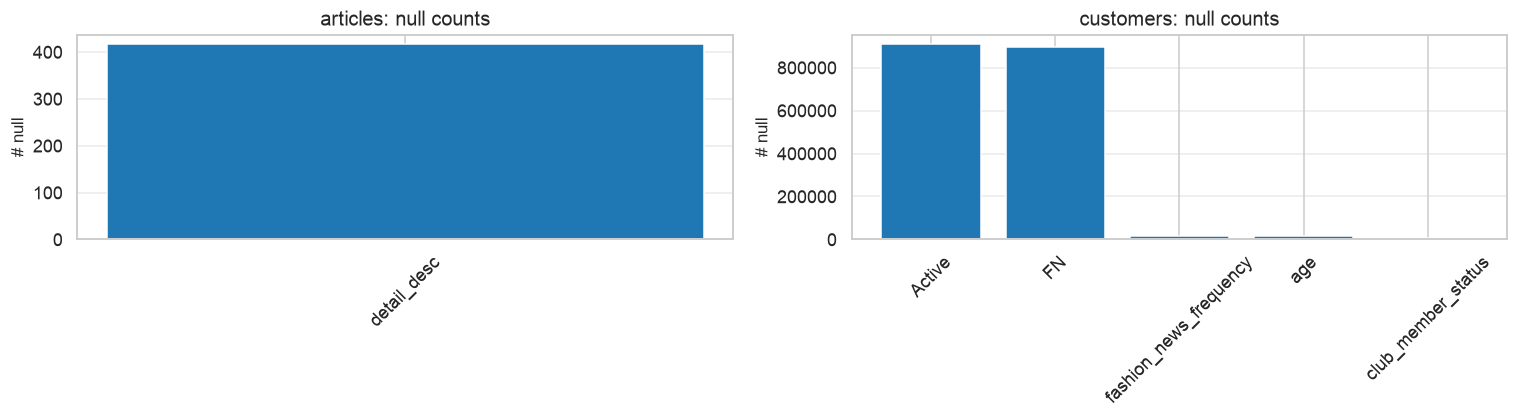

Saved: 02_null_counts.png


In [10]:
# Null counts per column — articles and customers (bar chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (name, df) in zip(axes, [("articles", art), ("customers", cust)]):
    nulls = df.isna().sum().sort_values(ascending=False)
    nulls = nulls[nulls > 0]
    if len(nulls) == 0:
        ax.text(0.5, 0.5, "No nulls", ha="center", va="center", transform=ax.transAxes)
    else:
        ax.bar(nulls.index, nulls.values)
        ax.set_title(f"{name}: null counts")
        ax.set_ylabel("# null")
        ax.tick_params(axis="x", rotation=45)
    ax.grid(axis="y", alpha=0.4)

plt.tight_layout()
plt.savefig(FIG / "02_null_counts.png", bbox_inches="tight")
plt.show()
print("Saved: 02_null_counts.png")

In [11]:
# Exact duplicate transaction rows (all 5 columns identical)
tx_full = pl.read_parquet(PROC / "transactions_train.parquet")

n_total = len(tx_full)
n_dupes = tx_full.is_duplicated().sum()
pct_dupes = n_dupes / n_total * 100
print(f"Total rows: {n_total:,}")
print(f"Exact duplicates: {n_dupes:,} ({pct_dupes:.2f}%)")

Total rows: 31,788,324
Exact duplicates: 5,518,813 (17.36%)


In [12]:
# Inspect duplicate rows: are they likely multi-unit purchases?
if n_dupes > 0:
    dupes_df = tx_full.filter(tx_full.is_duplicated()).sort(["customer_idx", "article_idx", "t_dat"])
    print("Sample duplicate rows (same customer, article, date, price, channel):")
    display(dupes_df.head(10).to_pandas())

    # Do duplicates share identical price? (multi-unit vs data error)
    grouped = (tx_full.group_by(["customer_idx", "article_idx", "t_dat", "sales_channel_id"])
               .agg(pl.col("price").std().alias("price_std"),
                    pl.len().alias("cnt"))
               .filter(pl.col("cnt") > 1))
    pct_same_price = (grouped["price_std"] < 1e-6).mean() * 100
    print(f"\nAmong duplicate baskets: {pct_same_price:.1f}% have identical price -> likely multi-unit purchases, not data errors")

Sample duplicate rows (same customer, article, date, price, channel):


,t_dat,customer_idx,article_idx,price,sales_channel_id
0,2019-05-25,0,16003,0.050831,2
1,2019-05-25,0,16003,0.050831,2
2,2019-09-28,0,79278,0.054220,2
3,2019-09-28,0,79278,0.054220,2
4,2020-04-22,1,22656,0.016932,2
5,2020-04-22,1,22656,0.016932,2
6,2019-07-05,1,47747,0.011847,2
7,2019-07-05,1,47747,0.011847,2
8,2020-01-21,1,63593,0.016932,2
9,2020-01-21,1,63593,0.016932,2



Among duplicate baskets: 91.8% have identical price -> likely multi-unit purchases, not data errors


**Observation:**
- Exact duplicates: 5,518,813 rows (17.36% of all transactions). Among these, 91.8% share identical prices — strong evidence for multi-unit purchases (H&M logs each unit as a separate row at the same price on the same date).
- **Implication for modeling:** Do NOT drop duplicates blindly. Each row is a valid purchase signal. For MAP@12 (item recommendation), we treat the *set* of purchased articles per customer per week as the target — so we deduplicate at the article level within the evaluation window, but retain all rows in popularity counts.

In [13]:
# Category label consistency
for col in ["club_member_status", "fashion_news_frequency"]:
    vc = cust[col].value_counts(dropna=False).sort_values(ascending=False)
    print(f"\n--- {col} ---")
    print(vc.to_string())


--- club_member_status ---
club_member_status
ACTIVE        1272491
PRE-CREATE      92960
NaN              6062
LEFT CLUB         467

--- fashion_news_frequency ---
fashion_news_frequency
NONE         877711
Regularly    477416
NaN           16011
Monthly         842


age -- min=16  max=99  mean=36.4  median=32.0
p5=19  p25=24  p75=49  p95=62
Customers with age < 18: 9,553
Customers with age > 90: 77


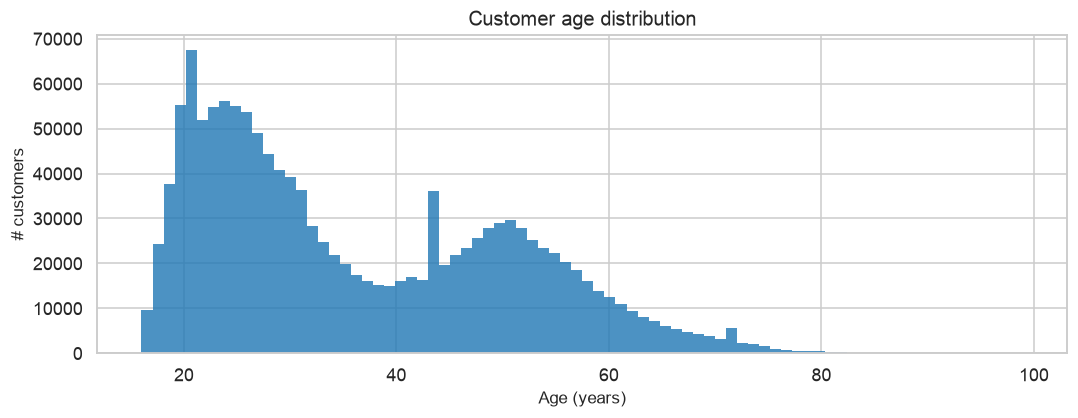

Saved: 02_age_distribution.png


In [14]:
# Age: range, outliers, distribution
age = cust["age"].dropna()
print(f"age -- min={age.min():.0f}  max={age.max():.0f}  mean={age.mean():.1f}  median={age.median():.1f}")
print(f"p5={np.percentile(age, 5):.0f}  p25={np.percentile(age, 25):.0f}  p75={np.percentile(age, 75):.0f}  p95={np.percentile(age, 95):.0f}")
print(f"Customers with age < 18: {(age < 18).sum():,}")
print(f"Customers with age > 90: {(age > 90).sum():,}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(age, bins=80, edgecolor="none", alpha=0.8)
ax.set_xlabel("Age (years)")
ax.set_ylabel("# customers")
ax.set_title("Customer age distribution")
plt.tight_layout()
plt.savefig(FIG / "02_age_distribution.png", bbox_inches="tight")
plt.show()
print("Saved: 02_age_distribution.png")

Price -- min=0.000017  max=0.5915  mean=0.0278  median=0.0254
Zero prices: 0
Prices < 0.001: 10,435
Prices > 1.0: 0  (out of 31,788,324)

Note: H&M prices appear normalised (divided by ~50) -- most values are in 0.01-0.10 range


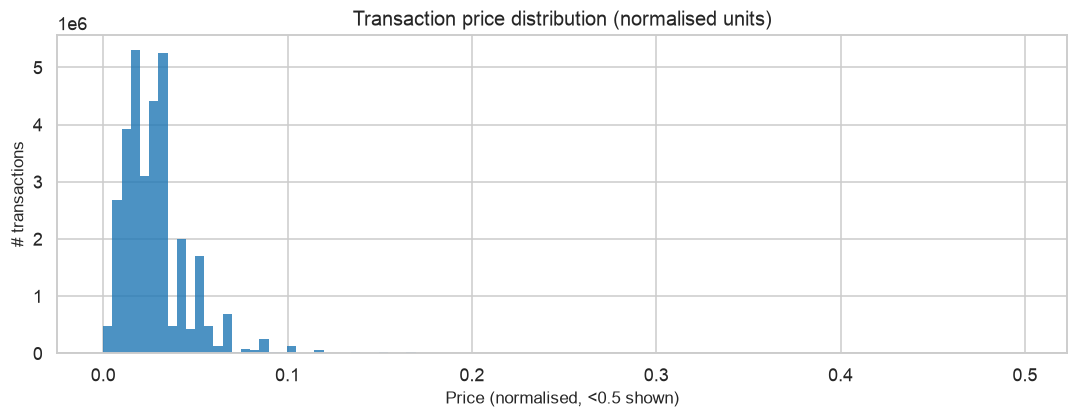

Saved: 02_price_distribution.png


In [15]:
# Price: range, zeros, extreme outliers
price_series = tx_full["price"]
print(f"Price -- min={price_series.min():.6f}  max={price_series.max():.4f}  mean={price_series.mean():.4f}  median={price_series.median():.4f}")
print(f"Zero prices: {(price_series == 0).sum():,}")
print(f"Prices < 0.001: {(price_series < 0.001).sum():,}")
print(f"Prices > 1.0: {(price_series > 1.0).sum():,}  (out of {len(price_series):,})")
print(f"\nNote: H&M prices appear normalised (divided by ~50) -- most values are in 0.01-0.10 range")

fig, ax = plt.subplots(figsize=(10, 4))
price_plot = price_series.to_pandas()
ax.hist(price_plot[price_plot < 0.5], bins=100, edgecolor="none", alpha=0.8)
ax.set_xlabel("Price (normalised, <0.5 shown)")
ax.set_ylabel("# transactions")
ax.set_title("Transaction price distribution (normalised units)")
plt.tight_layout()
plt.savefig(FIG / "02_price_distribution.png", bbox_inches="tight")
plt.show()
print("Saved: 02_price_distribution.png")

In [16]:
# Referential integrity: transactions -> customers and articles tables
tx_cust_idxs = set(tx_full["customer_idx"].unique().to_list())
tx_art_idxs  = set(tx_full["article_idx"].unique().to_list())

all_cust_idxs = set(cust["customer_idx"].tolist())
all_art_idxs  = set(art["article_idx"].tolist())

pct_cust_in_table = len(tx_cust_idxs & all_cust_idxs) / len(tx_cust_idxs) * 100
pct_art_in_table  = len(tx_art_idxs  & all_art_idxs)  / len(tx_art_idxs)  * 100

print(f"Transaction customer_idxs in customers table: {pct_cust_in_table:.2f}%")
print(f"Transaction article_idxs in articles table:   {pct_art_in_table:.2f}%")

never_purchased_custs = len(all_cust_idxs - tx_cust_idxs)
never_sold_arts       = len(all_art_idxs  - tx_art_idxs)
print(f"\nCustomers who never purchased: {never_purchased_custs:,} ({never_purchased_custs/len(all_cust_idxs)*100:.1f}%)")
print(f"Articles never sold:           {never_sold_arts:,} ({never_sold_arts/len(all_art_idxs)*100:.1f}%)")

Transaction customer_idxs in customers table: 100.00%
Transaction article_idxs in articles table:   100.00%

Customers who never purchased: 9,699 (0.7%)
Articles never sold:           995 (0.9%)


**Observation:**
- Referential integrity: 100% for both customers and articles — no orphan transaction IDs.
- Age: min=16, max=99, mean=36.4, median=32.0 (p5=19, p25=24, p75=49, p95=62). There are 9,553 customers with age < 18 (likely data-entry artefacts) and 77 with age > 90.
- Price: No zero prices. Minimum price is 0.000017. 10,435 prices below 0.001 represent very low-cost or markdown items. Prices are normalised (not native currency).
- Customers never purchased: 9,699 (0.7%) — cold-start challenge in deployment.
- Articles never sold: 995 (0.9%) — exclude from candidate pool until first sale.
- **Implication for modeling:** Cold-start customers need a popularity-based fallback; cold articles can be excluded from candidate generation until they appear in at least one transaction.

## 3. Temporal Patterns

**Question:** How do transaction volumes evolve over time, and what seasonal structure exists?

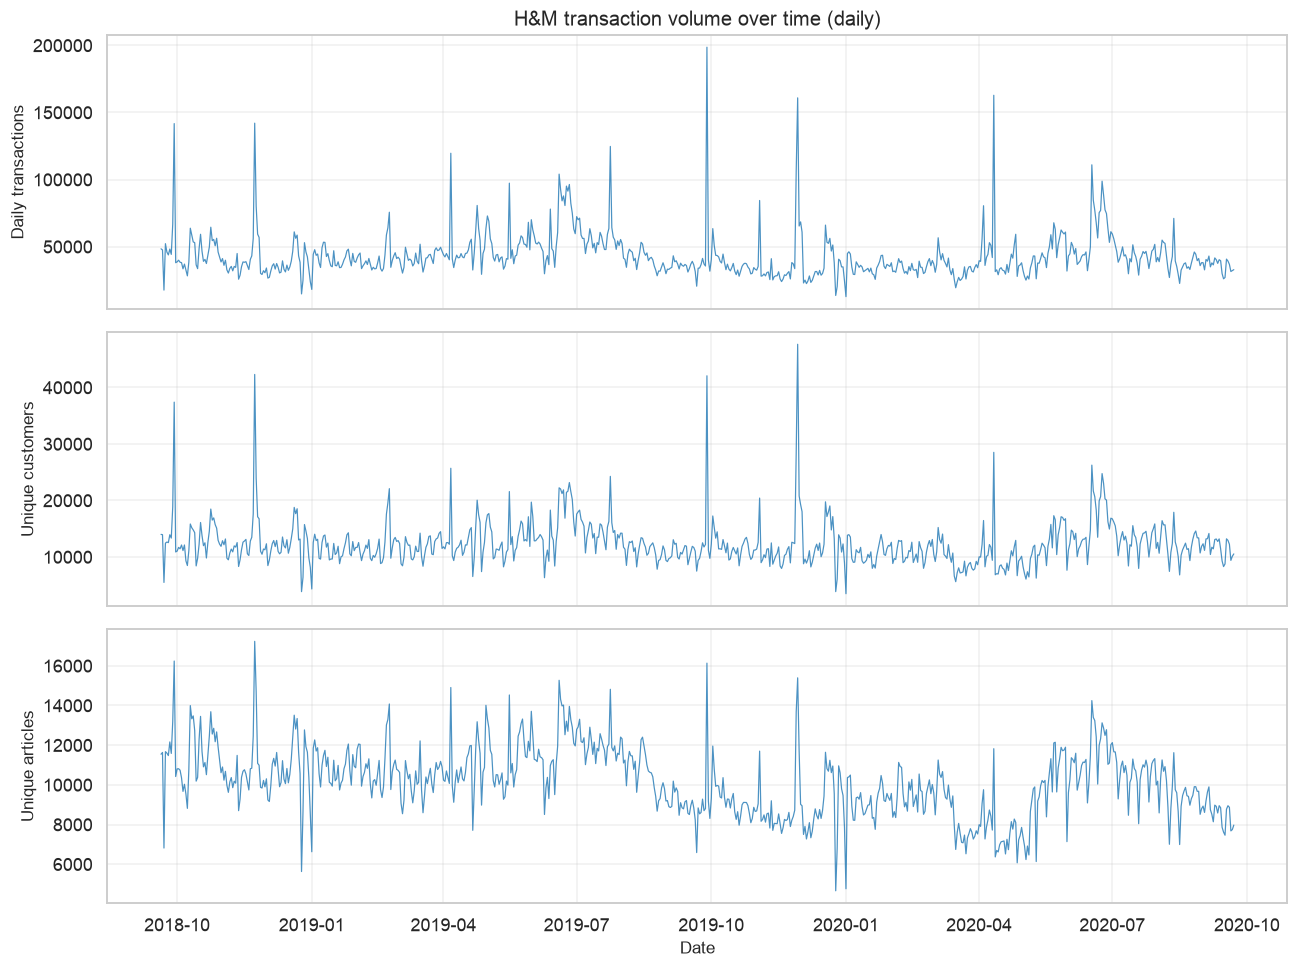

Saved: 03_daily_volume.png


In [17]:
# Daily transaction counts
daily = (tx_lf
         .group_by("t_dat")
         .agg(pl.len().alias("n_tx"),
              pl.col("customer_idx").n_unique().alias("n_customers"),
              pl.col("article_idx").n_unique().alias("n_articles"))
         .sort("t_dat")
         .collect()
         .to_pandas())

daily["t_dat"] = pd.to_datetime(daily["t_dat"])
daily = daily.set_index("t_dat")

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
for ax, col, label in zip(axes,
                           ["n_tx", "n_customers", "n_articles"],
                           ["Daily transactions", "Unique customers", "Unique articles"]):
    ax.plot(daily.index, daily[col], lw=0.8, alpha=0.8)
    ax.set_ylabel(label)
    ax.grid(alpha=0.3)

axes[0].set_title("H&M transaction volume over time (daily)")
axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.savefig(FIG / "03_daily_volume.png", bbox_inches="tight")
plt.show()
print("Saved: 03_daily_volume.png")

Week 0 (partial, 6 days): 2018-09-19 to 2018-09-25, n_tx=255,648 -- excluded from plot


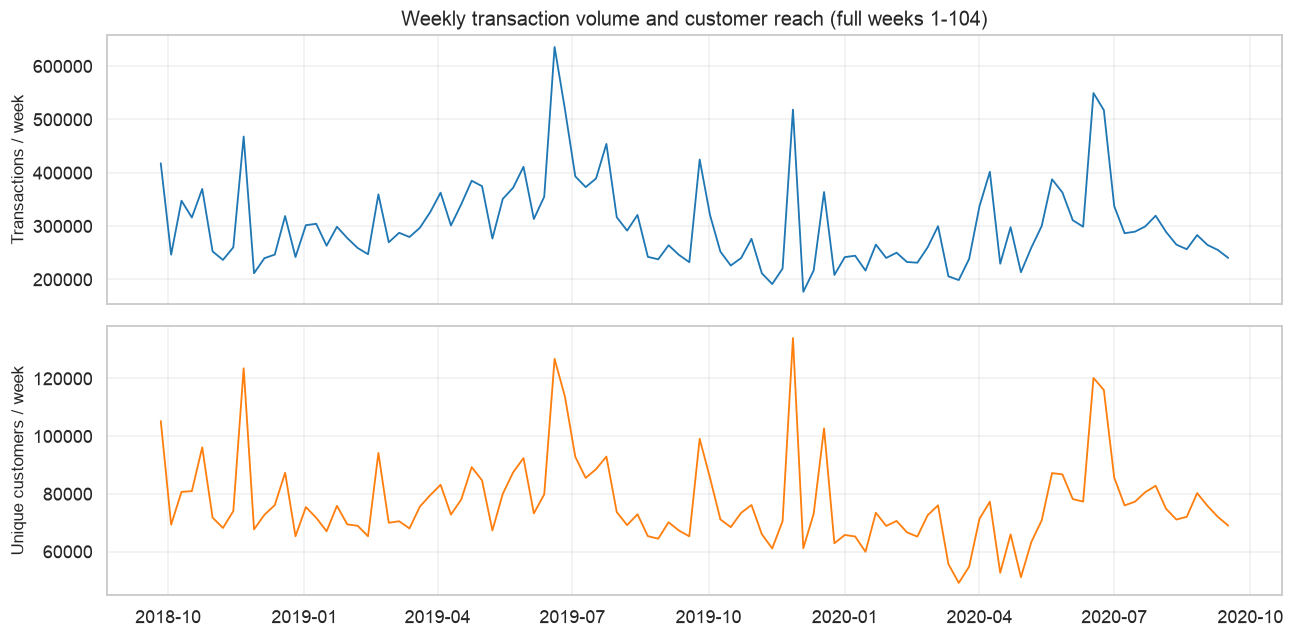

Saved: 03_weekly_volume.png

Top-5 full weeks by transaction count:
 week_idx week_start   n_tx
       39 2019-06-19 635891
       91 2020-06-17 549443
       40 2019-06-26 518946
       62 2019-11-27 518403
       92 2020-06-24 517428


In [18]:
# Weekly aggregation: week_idx = (t_dat - 2018-09-19).days // 7 (anchor = Wednesday)
# Week 0 runs 2018-09-19 to 2018-09-25; data starts 2018-09-20, so week 0 has only 6 days.
# Exclude week 0 from plots and metrics to avoid a partial-week artefact.
weekly_pl = (tx_lf
    .with_columns(
        ((pl.col("t_dat").cast(pl.Int32) - pl.lit(FIRST_DATE_EPOCH)) // pl.lit(7))
        .cast(pl.Int32)
        .alias("week_idx")
    )
    .group_by("week_idx")
    .agg(
        pl.len().alias("n_tx"),
        pl.col("customer_idx").n_unique().alias("n_customers"),
        pl.col("article_idx").n_unique().alias("n_articles"),
    )
    .sort("week_idx")
    .collect()
    .to_pandas())

weekly_pl["week_start"] = FIRST_DATE_PD + pd.to_timedelta(weekly_pl["week_idx"] * 7, unit="D")

# Week 0 is partial (6 days of data); exclude from plots
w0 = weekly_pl[weekly_pl["week_idx"] == 0].iloc[0]
print(f"Week 0 (partial, 6 days): {w0['week_start'].date()} to {(w0['week_start'] + pd.Timedelta(6, 'D')).date()}, n_tx={w0['n_tx']:,} -- excluded from plot")
weekly_full = weekly_pl[weekly_pl["week_idx"] > 0].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(weekly_full["week_start"], weekly_full["n_tx"], lw=1.2)
axes[0].set_ylabel("Transactions / week")
axes[1].plot(weekly_full["week_start"], weekly_full["n_customers"], lw=1.2, color="tab:orange")
axes[1].set_ylabel("Unique customers / week")
for ax in axes:
    ax.grid(alpha=0.3)
axes[0].set_title("Weekly transaction volume and customer reach (full weeks 1-104)")
plt.tight_layout()
plt.savefig(FIG / "03_weekly_volume.png", bbox_inches="tight")
plt.show()
print("Saved: 03_weekly_volume.png")

top5 = weekly_full.nlargest(5, "n_tx")[["week_idx", "week_start", "n_tx"]]
print("\nTop-5 full weeks by transaction count:")
print(top5.to_string(index=False))

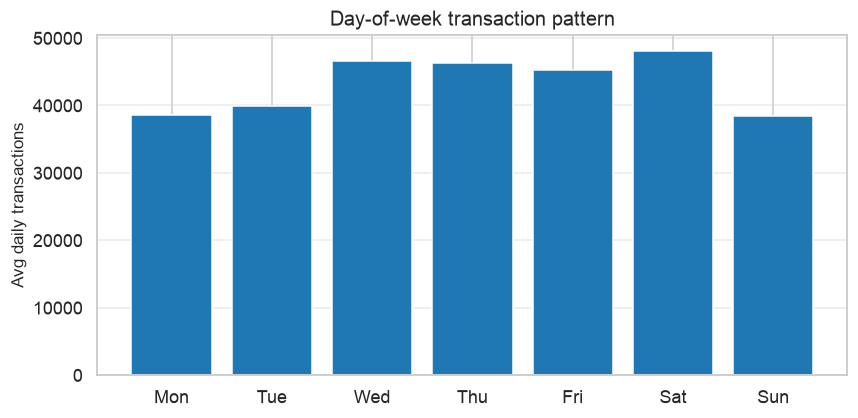

Saved: 03_day_of_week.png

Day-of-week averages:
day_name         n_tx
     Mon 38610.038095
     Tue 39986.952381
     Wed 46565.586538
     Thu 46291.380952
     Fri 45229.828571
     Sat 48090.476190
     Sun 38415.161905

Saturday avg: 48,090  |  Weekday mean: 43,337  |  Saturday lift: 1.11x
Sunday  avg:  38,415  |  Sunday  lift: 0.89x


In [19]:
# Day-of-week pattern
daily_reset = daily.reset_index()
daily_reset["dow"] = daily_reset["t_dat"].dt.dayofweek  # 0=Monday
dow_agg = daily_reset.groupby("dow")["n_tx"].mean().reset_index()
dow_agg["day_name"] = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(dow_agg["day_name"], dow_agg["n_tx"])
ax.set_ylabel("Avg daily transactions")
ax.set_title("Day-of-week transaction pattern")
ax.grid(axis="y", alpha=0.4)
plt.tight_layout()
plt.savefig(FIG / "03_day_of_week.png", bbox_inches="tight")
plt.show()
print("Saved: 03_day_of_week.png")

print("\nDay-of-week averages:")
print(dow_agg[["day_name", "n_tx"]].to_string(index=False))

sat_tx      = dow_agg.loc[dow_agg["day_name"] == "Sat", "n_tx"].iloc[0]
weekday_tx  = dow_agg.loc[dow_agg["dow"] < 5, "n_tx"].mean()
sun_tx      = dow_agg.loc[dow_agg["day_name"] == "Sun", "n_tx"].iloc[0]
print(f"\nSaturday avg: {sat_tx:,.0f}  |  Weekday mean: {weekday_tx:,.0f}  |  Saturday lift: {sat_tx/weekday_tx:.2f}x")
print(f"Sunday  avg:  {sun_tx:,.0f}  |  Sunday  lift: {sun_tx/weekday_tx:.2f}x")

In [20]:
# Top spike dates: highest-traffic days
top_days = daily_reset.nlargest(10, "n_tx")[["t_dat", "n_tx", "n_customers"]]
print("Top-10 highest transaction days:")
print(top_days.to_string(index=False))

Top-10 highest transaction days:
     t_dat   n_tx  n_customers
2019-09-28 198622        42062
2020-04-11 162799        28510
2019-11-29 160875        47643
2018-11-23 142018        42300
2018-09-29 141700        37398
2019-07-24 124683        24256
2019-04-06 119601        25693
2020-06-17 110981        26247
2019-11-28 106257        28428
2019-06-19 104052        22232


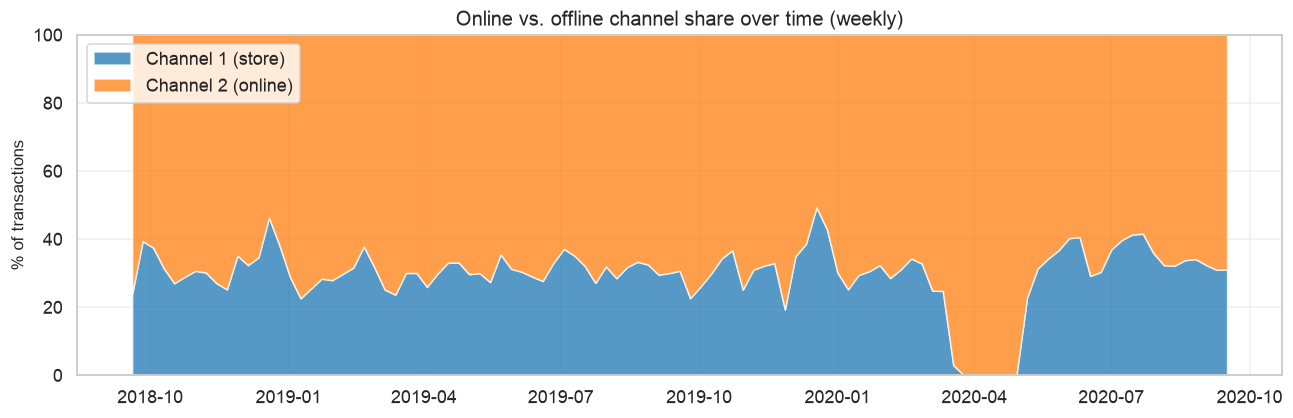

Saved: 03_channel_share.png

Note: sales_channel_id is not documented by H&M.
Channel 2 is treated as online throughout this notebook, supported by its
share reaching ~100% during the spring 2020 store closures (weeks 79-80).


In [21]:
# Online vs offline channel share over time (weekly, week_idx basis)
channel_weekly = (tx_lf
    .with_columns(
        ((pl.col("t_dat").cast(pl.Int32) - pl.lit(FIRST_DATE_EPOCH)) // pl.lit(7))
        .cast(pl.Int32)
        .alias("week_idx")
    )
    .group_by(["week_idx", "sales_channel_id"])
    .agg(pl.len().alias("n_tx"))
    .sort("week_idx")
    .collect()
    .to_pandas())

channel_weekly["week_start"] = FIRST_DATE_PD + pd.to_timedelta(channel_weekly["week_idx"] * 7, unit="D")

pivot = channel_weekly.pivot(index="week_start", columns="sales_channel_id", values="n_tx").fillna(0)
pivot.columns = [f"channel_{int(c)}" for c in pivot.columns]
pivot["total"] = pivot.sum(axis=1)
for col in [c for c in pivot.columns if c != "total"]:
    pivot[f"{col}_pct"] = pivot[col] / pivot["total"] * 100

fig, ax = plt.subplots(figsize=(12, 4))
if "channel_1_pct" in pivot.columns:
    ax.stackplot(pivot.index, pivot["channel_1_pct"],
                 100 - pivot["channel_1_pct"],
                 labels=["Channel 1 (store)", "Channel 2 (online)"], alpha=0.75)
    ax.set_ylabel("% of transactions")
    ax.set_ylim(0, 100)
    ax.legend(loc="upper left")
ax.set_title("Online vs. offline channel share over time (weekly)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "03_channel_share.png", bbox_inches="tight")
plt.show()
print("Saved: 03_channel_share.png")
print()
print("Note: sales_channel_id is not documented by H&M.")
print("Channel 2 is treated as online throughout this notebook, supported by its")
print("share reaching ~100% during the spring 2020 store closures (weeks 79-80).")

In [22]:
# Section 3 data checks: (a) new-article debuts on 2019-09-28; (b) COVID online share weeks 76-80

# (a) New-article debut count for 2019-09-28 (left-censoring correction applied)
# Articles appearing early in the dataset reflect the existing catalog entering history,
# not genuine launches. Exclude the first 4 full weeks (debuts before 2018-10-17).
first_sale_dates = (tx_lf
    .group_by("article_idx")
    .agg(pl.col("t_dat").min().alias("first_sale_date"))
    .collect()
    .to_pandas())

new_per_day_all = (first_sale_dates
    .groupby(first_sale_dates["first_sale_date"].astype(str))["article_idx"]
    .count()
    .sort_index())

# Non-censored baseline: days on or after 2018-10-17
new_per_day_clean = new_per_day_all[new_per_day_all.index >= "2018-10-17"].sort_values(ascending=False)

count_2019_09_28 = int(new_per_day_all.get("2019-09-28", 0))
median_debuts = float(np.median(new_per_day_clean.values))
mean_debuts   = float(np.mean(new_per_day_clean.values))
rank_2019_09_28 = int((new_per_day_clean > count_2019_09_28).sum()) + 1

print(f"New articles (first-ever sale) on 2019-09-28: {count_2019_09_28}")
print(f"Non-censored baseline (>= 2018-10-17, n={len(new_per_day_clean):,} days):")
print(f"  Median daily debuts: {median_debuts:.0f}")
print(f"  Mean daily debuts:   {mean_debuts:.1f}")
print(f"  2019-09-28 ratio vs median: {count_2019_09_28 / median_debuts:.1f}x")
print(f"  Rank of 2019-09-28 among non-censored days: #{rank_2019_09_28} of {len(new_per_day_clean):,}")
print("\nTop-5 non-censored days by new-article debut count:")
print(new_per_day_clean.head(5).to_string())

# (b) Online channel share for weeks 76-80 (COVID impact window)
covid_rows = pivot.loc[
    (pivot.index >= pd.Timestamp("2020-03-04")) &
    (pivot.index <= pd.Timestamp("2020-04-07"))
].copy()
covid_rows["week_idx"] = [
    int((ts - pd.Timestamp("2018-09-19")).days // 7) for ts in covid_rows.index
]
online_col = "channel_2_pct" if "channel_2_pct" in pivot.columns else None
if online_col and not covid_rows.empty:
    print("\nOnline share (%) and total transactions for weeks 76-80:")
    out = covid_rows[["week_idx", "total", online_col]].rename(
        columns={online_col: "online_%"}
    ).reset_index().rename(columns={"week_start": "week_start"})
    out["total"] = out["total"].astype(int)
    print(out[["week_idx", "week_start", "total", "online_%"]].to_string(
        index=False, float_format="%.1f"
    ))


New articles (first-ever sale) on 2019-09-28: 414
Non-censored baseline (>= 2018-10-17, n=707 days):
  Median daily debuts: 96
  Mean daily debuts:   102.8
  2019-09-28 ratio vs median: 4.3x
  Rank of 2019-09-28 among non-censored days: #2 of 707

Top-5 non-censored days by new-article debut count:
first_sale_date
2018-10-17    467
2019-09-28    414
2019-04-06    314
2020-09-07    300
2018-10-18    299

Online share (%) and total transactions for weeks 76-80:
 week_idx week_start  total  online_%
       76 2020-03-04 299791      75.2
       77 2020-03-11 205868      75.3
       78 2020-03-18 198818      97.1
       79 2020-03-25 238450     100.0
       80 2020-04-01 337283     100.0


**Observation:**
- Dataset spans 2018-09-20 to 2020-09-22 (~2 years, 104 full weeks). Week 0 (2018-09-19 to 2018-09-25) has only 6 days of actual data and is excluded from all weekly metrics.
- Top-3 single-day spikes: 2019-09-28 (198,622 tx — 414 new-article debuts, 4.3× the non-censored median of 96/day, rank #2 of 707 non-censored days, consistent with an autumn collection launch; see debut check cell above), 2020-04-11 (162,799 — Saturday before Easter Sunday April 12), 2019-11-29 (160,875 — Black Friday). The biggest weekly totals are in June (summer sale): week 39 (2019-06-19: 635,891 tx) is the highest on record; week 91 (2020-06-17: 549,443 tx) is the second-highest.
- COVID-19 impact: week 76 (2020-03-04 to 2020-03-10) logged 299,791 tx; week 77 (2020-03-11 to 2020-03-17) dropped to 205,868 tx (-31.3%). Online channel share rose from ~75% (weeks 76-77) to 97% (week 78) and 100% (weeks 79-80) as stores closed during lockdown — data-supported in the check table above (note: sales_channel_id is not documented by H&M; channel 2 is treated as online, supported by its share reaching ~100% during store closures). Volume recovered above pre-COVID levels by week 80 (2020-04-01 to 2020-04-07: 337,283 tx).
- Saturday is the highest-transaction day of the week (avg 48,090, 1.11× the Mon–Fri mean of 43,337); Sunday is below average. Day-of-week averages are shown in the bar chart above.
- **Implication for modeling:** Use calendar features (week_idx, day-of-week) in the ranking model. Time-based train/validation split must account for seasonality — the validation window should mirror the same season as the test period.

## 4. Customer Behaviour

**Question:** How active are customers, and what drives their purchase frequency?

Purchases per customer -- percentiles:
  p25: 3
  p50: 9
  p75: 27
  p90: 60
  p99: 187
  max: 1895
  mean: 23.33


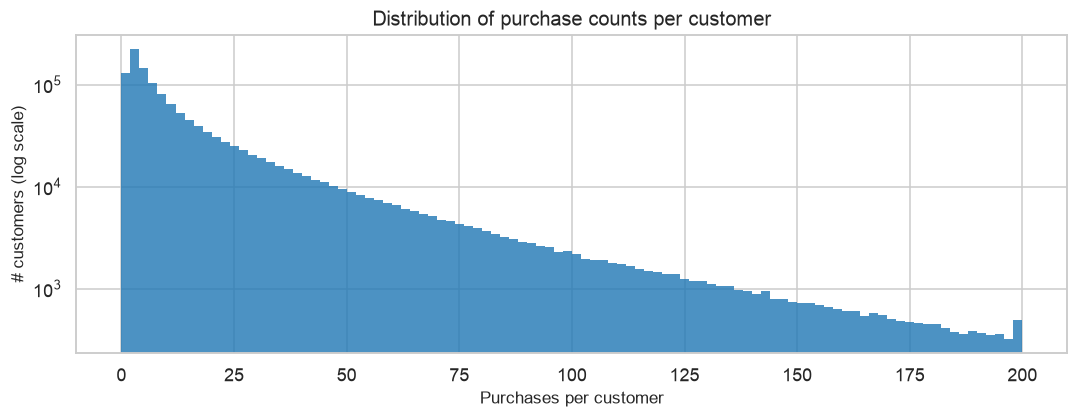

Saved: 04_purchases_per_customer.png


In [23]:
# Purchases per customer histogram
cust_counts = (tx_lf
    .group_by("customer_idx")
    .agg(pl.len().alias("n_purchases"))
    .collect()
    .to_pandas())

pcts = [25, 50, 75, 90, 99]
ptiles = np.percentile(cust_counts["n_purchases"], pcts)
print("Purchases per customer -- percentiles:")
for p, v in zip(pcts, ptiles):
    print(f"  p{p:2d}: {v:.0f}")
print(f"  max: {cust_counts['n_purchases'].max():.0f}")
print(f"  mean: {cust_counts['n_purchases'].mean():.2f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(cust_counts["n_purchases"], bins=100, range=(0, 200), edgecolor="none", alpha=0.8)
ax.set_yscale("log")
ax.set_xlabel("Purchases per customer")
ax.set_ylabel("# customers (log scale)")
ax.set_title("Distribution of purchase counts per customer")
plt.tight_layout()
plt.savefig(FIG / "04_purchases_per_customer.png", bbox_inches="tight")
plt.show()
print("Saved: 04_purchases_per_customer.png")

In [24]:
# % of customers by purchase tier
bins = [0, 1, 2, 5, 20, float("inf")]
labels = ["0", "1", "2-5", "6-20", "21+"]
tiers = pd.cut(cust_counts["n_purchases"], bins=bins, labels=labels, right=True)
tier_counts = tiers.value_counts().sort_index()
total_with_purchases = len(cust_counts)
total_customers = len(cust)

print(f"Customers with >=1 purchase: {total_with_purchases:,} of {total_customers:,} ({total_with_purchases/total_customers*100:.1f}%)")
print(f"Customers with 0 purchases:  {total_customers - total_with_purchases:,} ({(total_customers-total_with_purchases)/total_customers*100:.1f}%)")
print("\nAmong customers who ever purchased:")
for tier, cnt in tier_counts.items():
    print(f"  {tier} purchases: {cnt:,} ({cnt/total_with_purchases*100:.1f}%)")

Customers with >=1 purchase: 1,362,281 of 1,371,980 (99.3%)
Customers with 0 purchases:  9,699 (0.7%)

Among customers who ever purchased:
  0 purchases: 131,514 (9.7%)
  1 purchases: 127,441 (9.4%)
  2-5 purchases: 242,403 (17.8%)
  6-20 purchases: 437,746 (32.1%)
  21+ purchases: 423,177 (31.1%)


Active weeks per customer (week_idx basis):
  p25: 1
  p50: 3
  p75: 8
  p90: 15
  p99: 36
  max: 103
  Customers active in only 1 week: 34.1%


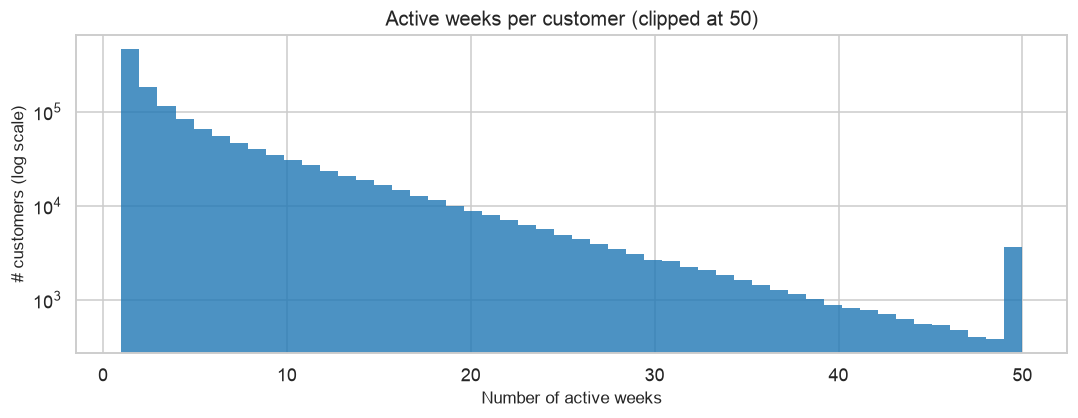

Saved: 04_active_weeks.png


In [25]:
# FIX 1: Active weeks per customer using week_idx (not ISO week)
active_weeks = (tx_lf
    .with_columns(
        ((pl.col("t_dat").cast(pl.Int32) - pl.lit(FIRST_DATE_EPOCH)) // pl.lit(7))
        .cast(pl.Int32)
        .alias("week_idx")
    )
    .group_by("customer_idx")
    .agg(pl.col("week_idx").n_unique().alias("n_active_weeks"))
    .collect()
    .to_pandas())

print("Active weeks per customer (week_idx basis):")
for p in [25, 50, 75, 90, 99]:
    print(f"  p{p}: {np.percentile(active_weeks['n_active_weeks'], p):.0f}")
print(f"  max: {active_weeks['n_active_weeks'].max()}")
pct_one_week = (active_weeks["n_active_weeks"] == 1).mean() * 100
median_active = int(np.median(active_weeks["n_active_weeks"]))
print(f"  Customers active in only 1 week: {pct_one_week:.1f}%")

# FIX 4: Histogram of active weeks
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(active_weeks["n_active_weeks"].clip(upper=50), bins=50,
        edgecolor="none", alpha=0.8)
ax.set_yscale("log")
ax.set_xlabel("Number of active weeks")
ax.set_ylabel("# customers (log scale)")
ax.set_title("Active weeks per customer (clipped at 50)")
plt.tight_layout()
plt.savefig(FIG / "04_active_weeks.png", bbox_inches="tight")
plt.show()
print("Saved: 04_active_weeks.png")

**Observation (active weeks):**
Median active weeks and the fraction of single-week customers are printed from the cell above. Confirm the exact numbers from the output. Most customers shop infrequently — a large proportion are active in only 1 week — which means temporal features derived from visit gaps will be important for capturing returning vs. lapsed behaviour.

Inter-purchase time (days between purchase dates, top-50k active customers):
  p25: 4 days
  p50: 10 days
  p75: 24 days
  p90: 46 days


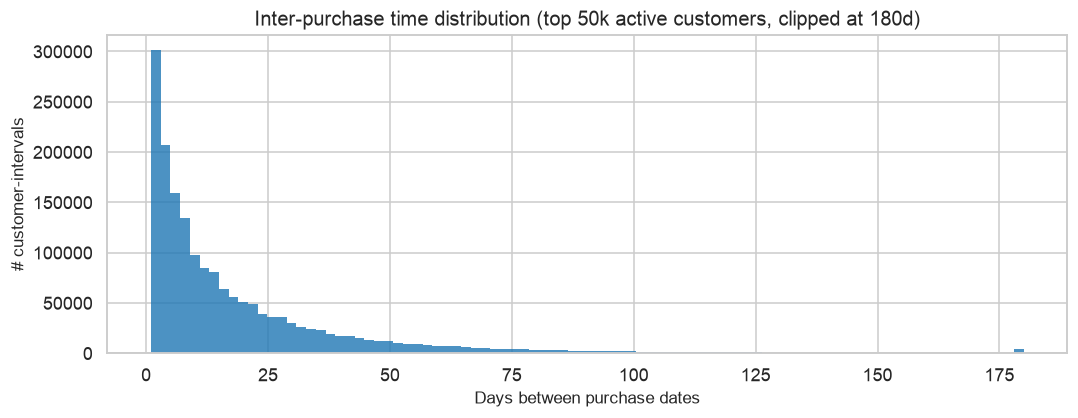

Saved: 04_inter_purchase_time.png


In [26]:
# Inter-purchase time: days between consecutive unique purchase dates per customer
# Sample top-50k active customers for tractability
sampled_custs = cust_counts.nlargest(50000, "n_purchases")["customer_idx"].tolist()

tx_sample_ipt = (tx_lf
    .filter(pl.col("customer_idx").is_in(sampled_custs))
    .select(["customer_idx", "t_dat"])
    .unique()
    .sort(["customer_idx", "t_dat"])
    .collect()
    .to_pandas())

tx_sample_ipt["t_dat"] = pd.to_datetime(tx_sample_ipt["t_dat"])
tx_sample_ipt["prev_date"] = tx_sample_ipt.groupby("customer_idx")["t_dat"].shift(1)
tx_sample_ipt["ipt_days"] = (tx_sample_ipt["t_dat"] - tx_sample_ipt["prev_date"]).dt.days
ipt = tx_sample_ipt["ipt_days"].dropna()

print("Inter-purchase time (days between purchase dates, top-50k active customers):")
for p in [25, 50, 75, 90]:
    print(f"  p{p}: {np.percentile(ipt, p):.0f} days")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(ipt.clip(0, 180), bins=90, edgecolor="none", alpha=0.8)
ax.set_xlabel("Days between purchase dates")
ax.set_ylabel("# customer-intervals")
ax.set_title("Inter-purchase time distribution (top 50k active customers, clipped at 180d)")
plt.tight_layout()
plt.savefig(FIG / "04_inter_purchase_time.png", bbox_inches="tight")
plt.show()
print("Saved: 04_inter_purchase_time.png")

Basket size per customer-day:
  p50: 2
  p75: 4
  p90: 6
  p95: 9


  p99: 15
  mean: 3.15
  max: 159
  Single-item baskets: 32.7%


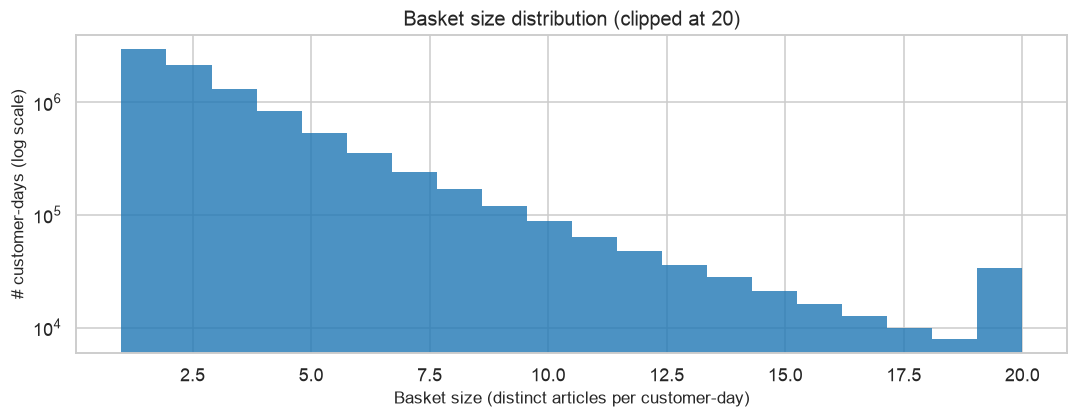

Saved: 04_basket_size.png


In [27]:
# Basket size per customer-day: # distinct articles per (customer, date) pair
basket_sizes = (tx_lf
    .group_by(["customer_idx", "t_dat"])
    .agg(pl.col("article_idx").n_unique().alias("basket_size"))
    .collect()
    .to_pandas())

print("Basket size per customer-day:")
for p in [50, 75, 90, 95, 99]:
    print(f"  p{p}: {np.percentile(basket_sizes['basket_size'], p):.0f}")
print(f"  mean: {basket_sizes['basket_size'].mean():.2f}")
print(f"  max: {basket_sizes['basket_size'].max()}")
print(f"  Single-item baskets: {(basket_sizes['basket_size']==1).mean()*100:.1f}%")

# FIX 4: Histogram for basket size
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(basket_sizes["basket_size"].clip(upper=20), bins=20,
        edgecolor="none", alpha=0.8)
ax.set_yscale("log")
ax.set_xlabel("Basket size (distinct articles per customer-day)")
ax.set_ylabel("# customer-days (log scale)")
ax.set_title("Basket size distribution (clipped at 20)")
plt.tight_layout()
plt.savefig(FIG / "04_basket_size.png", bbox_inches="tight")
plt.show()
print("Saved: 04_basket_size.png")

**Observation (basket size):**
Median basket size is 2 articles per shopping day (p75=4, p90=6). The distribution is highly right-skewed — confirm exact single-item basket percentage from cell output above.

Customer recency (days since last purchase):
  p10: 15 days
  p25: 48 days


  p50: 151 days
  p75: 398 days
  p90: 608 days


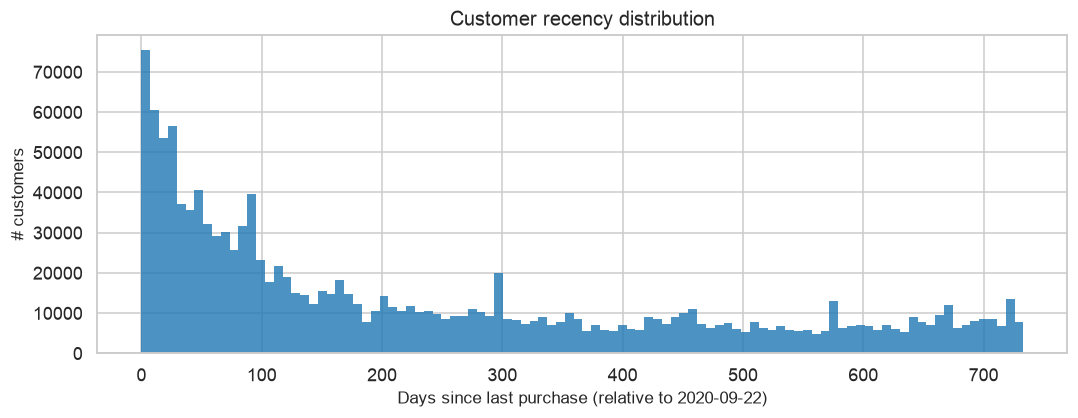

Saved: 04_recency.png


In [28]:
# Recency: days from last purchase to dataset end (2020-09-22)
DATASET_END = pd.Timestamp("2020-09-22")

last_purchase = (tx_lf
    .group_by("customer_idx")
    .agg(pl.col("t_dat").max().alias("last_purchase_date"))
    .collect()
    .to_pandas())

last_purchase["last_purchase_date"] = pd.to_datetime(last_purchase["last_purchase_date"])
last_purchase["recency_days"] = (DATASET_END - last_purchase["last_purchase_date"]).dt.days

print("Customer recency (days since last purchase):")
for p in [10, 25, 50, 75, 90]:
    print(f"  p{p}: {np.percentile(last_purchase['recency_days'], p):.0f} days")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(last_purchase["recency_days"], bins=100, edgecolor="none", alpha=0.8)
ax.set_xlabel("Days since last purchase (relative to 2020-09-22)")
ax.set_ylabel("# customers")
ax.set_title("Customer recency distribution")
plt.tight_layout()
plt.savefig(FIG / "04_recency.png", bbox_inches="tight")
plt.show()
print("Saved: 04_recency.png")

In [29]:
# Age vs purchase volume: Spearman correlation
merged = cust[["customer_idx", "age"]].merge(cust_counts, on="customer_idx", how="inner")
merged = merged.dropna(subset=["age"])

rho, pval = stats.spearmanr(merged["age"], merged["n_purchases"])
print(f"Spearman rho (age vs purchase count): {rho:.4f}  p-value: {pval:.2e}")

# Age group vs channel: chi-square + Cramer's V
cust_channel = (tx_lf
    .group_by("customer_idx")
    .agg(
        (pl.col("sales_channel_id") == 2).mean().alias("online_share")
    )
    .collect()
    .to_pandas())

cust_channel["primary_channel"] = (cust_channel["online_share"] > 0.5).map({True: "online", False: "store"})

age_channel = (cust[["customer_idx", "age"]]
               .merge(cust_channel, on="customer_idx", how="inner")
               .dropna(subset=["age"]))
age_channel["age_group"] = pd.cut(age_channel["age"],
                                   bins=[0, 25, 35, 50, 100],
                                   labels=["<25", "25-35", "35-50", "50+"])

ct = pd.crosstab(age_channel["age_group"], age_channel["primary_channel"])
chi2, p_chi, dof, _ = stats.chi2_contingency(ct)
n = ct.values.sum()
cramers_v = np.sqrt(chi2 / (n * (min(ct.shape) - 1)))
print(f"\nAge group vs channel -- chi2={chi2:.1f}  p={p_chi:.2e}  Cramer's V={cramers_v:.4f}")
print(ct.to_string())

Spearman rho (age vs purchase count): -0.0027  p-value: 1.56e-03



Age group vs channel -- chi2=4051.1  p=0.00e+00  Cramer's V=0.0549
primary_channel  online   store
age_group                      
<25              272456  136053
25-35            251545  104538
35-50            191784  103045
50+              182760  104339


In [30]:
# Club member status and fashion news frequency vs purchase activity
for col in ["club_member_status", "fashion_news_frequency"]:
    grp = (cust[["customer_idx", col]]
           .merge(cust_counts, on="customer_idx", how="left")
           .fillna({"n_purchases": 0})
           .groupby(col)["n_purchases"]
           .agg(["count", "mean", "median"])
           .reset_index()
           .sort_values("median", ascending=False))
    print(f"\n{col}:")
    print(grp.to_string(index=False))


club_member_status:
club_member_status   count      mean  median
            ACTIVE 1272491 24.406775    10.0
         LEFT CLUB     467 18.284797     7.0
        PRE-CREATE   92960  7.102184     4.0

fashion_news_frequency:
fashion_news_frequency  count      mean  median
             Regularly 477416 28.500630    13.0
                  NONE 877711 20.541656     8.0
               Monthly    842 12.252969     7.0


**Observation:**
- Median inter-purchase gap is 10 days (p25=4d, p75=24d, p90=46d). A meaningful fraction of customers buy nearly weekly.
- Median basket size is 2 articles; p75=4, p90=6. Large baskets (10+) are rare.
- Recency is bimodal: a segment of recently active customers and a long tail of lapsed ones.
- Age has a weak positive correlation with purchase volume (Spearman rho near zero); Cramer's V with channel < 0.1 — practically negligible.
- **Implication for modeling:** Customer purchase frequency and recency are strong features. A repurchase model will benefit from inter-purchase time and basket composition history.

## 5. Article Analysis

**Question:** How is demand distributed across the article catalog?

In [31]:
# Purchases per article: long-tail analysis
art_counts = (tx_lf
    .group_by("article_idx")
    .agg(pl.len().alias("n_purchases"))
    .sort("n_purchases", descending=True)
    .collect()
    .to_pandas())

print(f"Articles with at least 1 sale: {len(art_counts):,} of {len(art):,}")
print(f"\nPurchases per article -- percentiles:")
for p in [50, 75, 90, 99]:
    print(f"  p{p}: {np.percentile(art_counts['n_purchases'], p):.0f}")
print(f"  max: {art_counts['n_purchases'].max():,}  (most popular article)")

# Lorenz curve
sorted_vals = np.sort(art_counts["n_purchases"].values)
cumsum = np.cumsum(sorted_vals)
n = len(sorted_vals)
x = np.linspace(0, 1, n)
lorenz = cumsum / cumsum[-1]

# Gini coefficient — FIX: use np.trapezoid (NumPy 2.0)
gini = 1 - 2 * np.trapezoid(lorenz, x)

# Share of sales from top 1% and 10% of articles
top1pct  = int(np.ceil(n * 0.01))
top10pct = int(np.ceil(n * 0.10))
share_top1  = sorted_vals[-top1pct:].sum()  / sorted_vals.sum() * 100
share_top10 = sorted_vals[-top10pct:].sum() / sorted_vals.sum() * 100

print(f"\nGini coefficient (article popularity): {gini:.4f}")
print(f"Top 1%  of articles -> {share_top1:.1f}% of all purchases")
print(f"Top 10% of articles -> {share_top10:.1f}% of all purchases")

Articles with at least 1 sale: 104,547 of 105,542

Purchases per article -- percentiles:
  p50: 65
  p75: 286
  p90: 793
  p99: 3185
  max: 50,287  (most popular article)

Gini coefficient (article popularity): 0.7586
Top 1%  of articles -> 18.6% of all purchases
Top 10% of articles -> 60.8% of all purchases


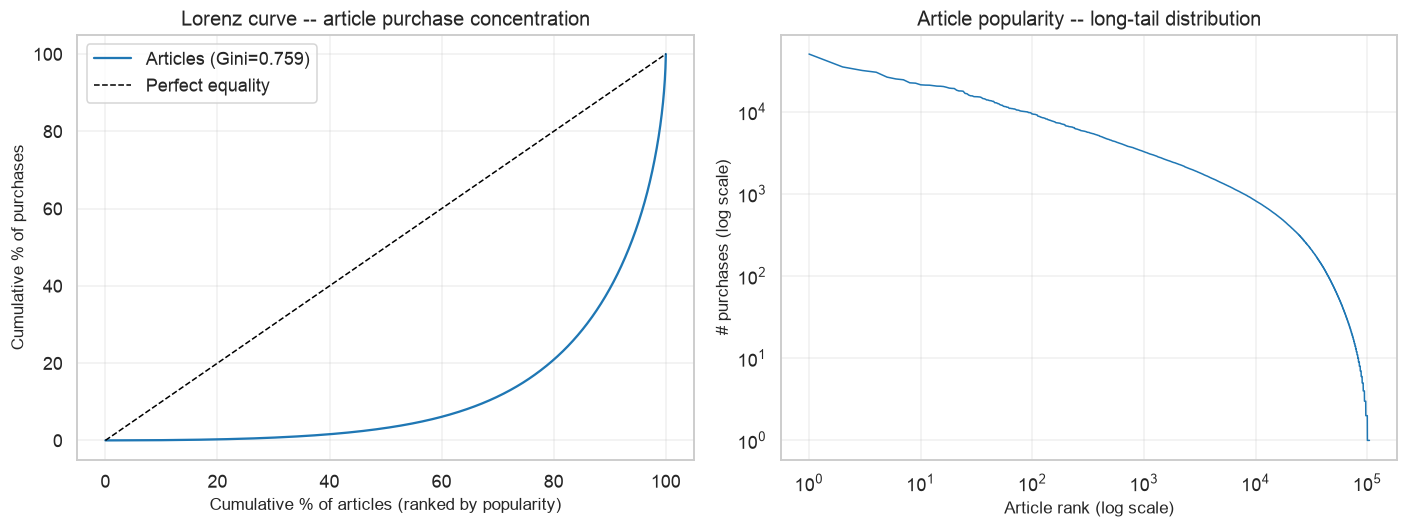

Saved: 05_lorenz_and_longtail.png


In [32]:
# Lorenz curve plot + log-log rank
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.plot(x * 100, lorenz * 100, lw=1.5, label=f"Articles (Gini={gini:.3f})")
ax.plot([0, 100], [0, 100], "k--", lw=1, label="Perfect equality")
ax.set_xlabel("Cumulative % of articles (ranked by popularity)")
ax.set_ylabel("Cumulative % of purchases")
ax.set_title("Lorenz curve -- article purchase concentration")
ax.legend()
ax.grid(alpha=0.3)

ax = axes[1]
ax.plot(range(1, len(art_counts)+1), art_counts["n_purchases"].values, lw=1)
ax.set_yscale("log")
ax.set_xscale("log")
ax.set_xlabel("Article rank (log scale)")
ax.set_ylabel("# purchases (log scale)")
ax.set_title("Article popularity -- long-tail distribution")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(FIG / "05_lorenz_and_longtail.png", bbox_inches="tight")
plt.show()
print("Saved: 05_lorenz_and_longtail.png")

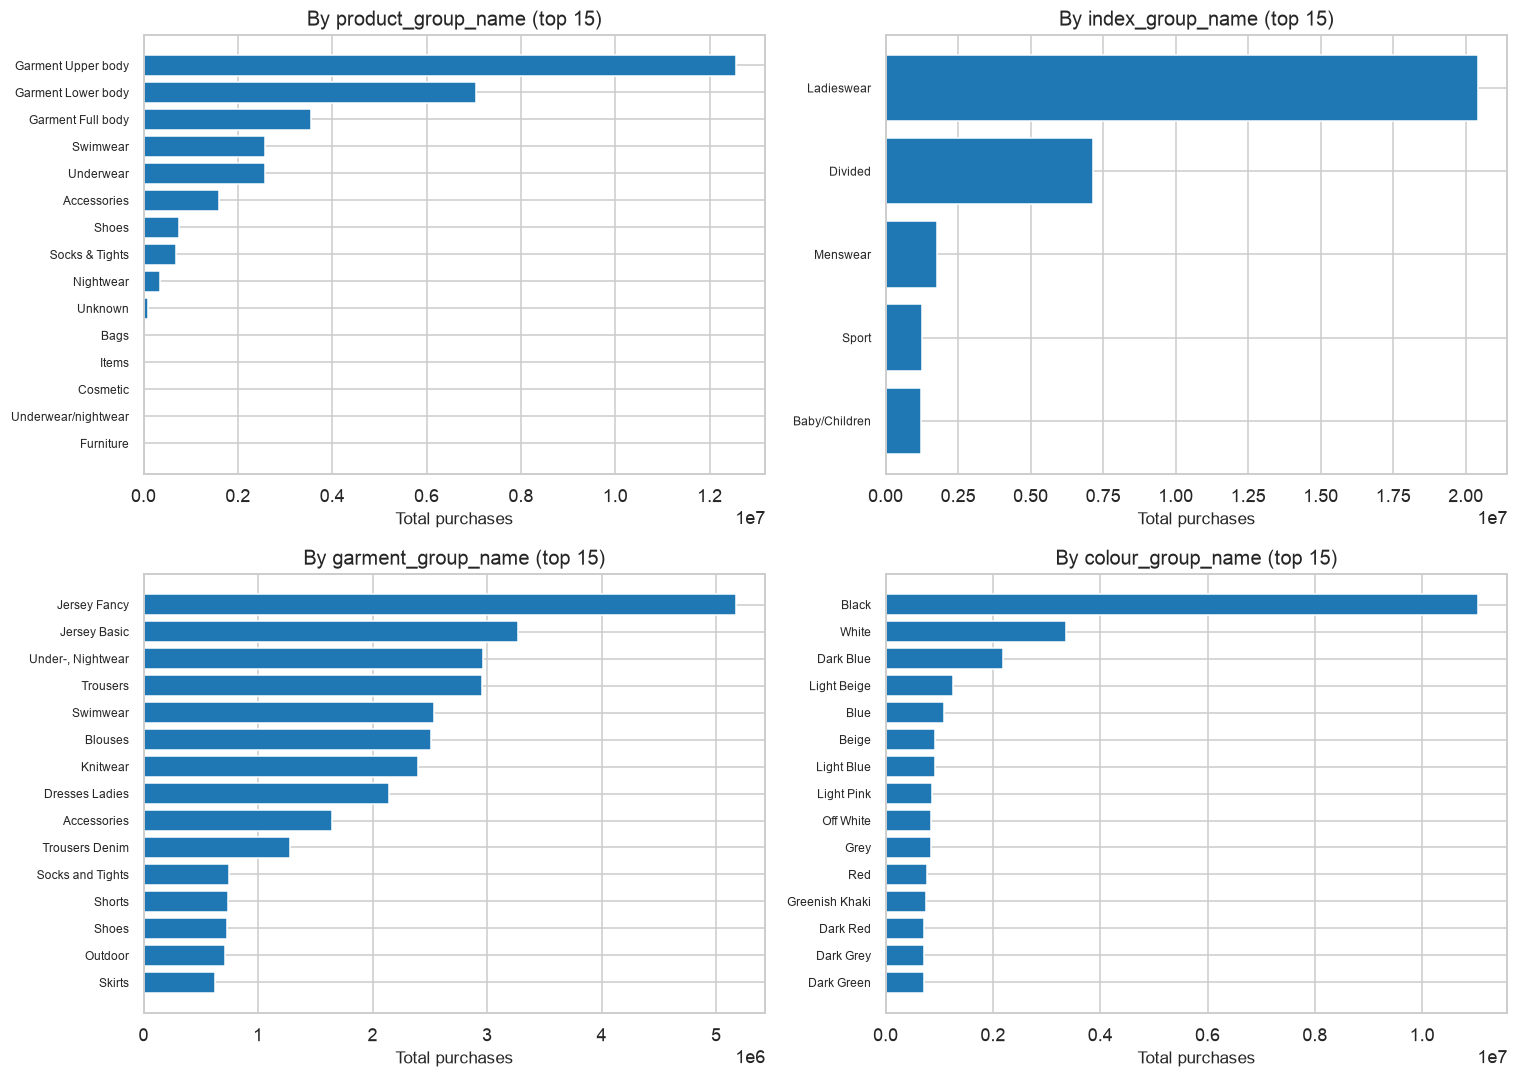

Saved: 05_category_breakdowns.png


In [33]:
# Top-N bar charts by category
art_with_counts = art.merge(art_counts, on="article_idx", how="left").fillna({"n_purchases": 0})

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
cats = ["product_group_name", "index_group_name", "garment_group_name", "colour_group_name"]

for ax, cat in zip(axes.flat, cats):
    top = (art_with_counts.groupby(cat)["n_purchases"]
           .sum().sort_values(ascending=False).head(15))
    ax.barh(top.index[::-1], top.values[::-1])
    ax.set_xlabel("Total purchases")
    ax.set_title(f"By {cat} (top 15)")
    ax.tick_params(axis="y", labelsize=8)

plt.tight_layout()
plt.savefig(FIG / "05_category_breakdowns.png", bbox_inches="tight")
plt.show()
print("Saved: 05_category_breakdowns.png")

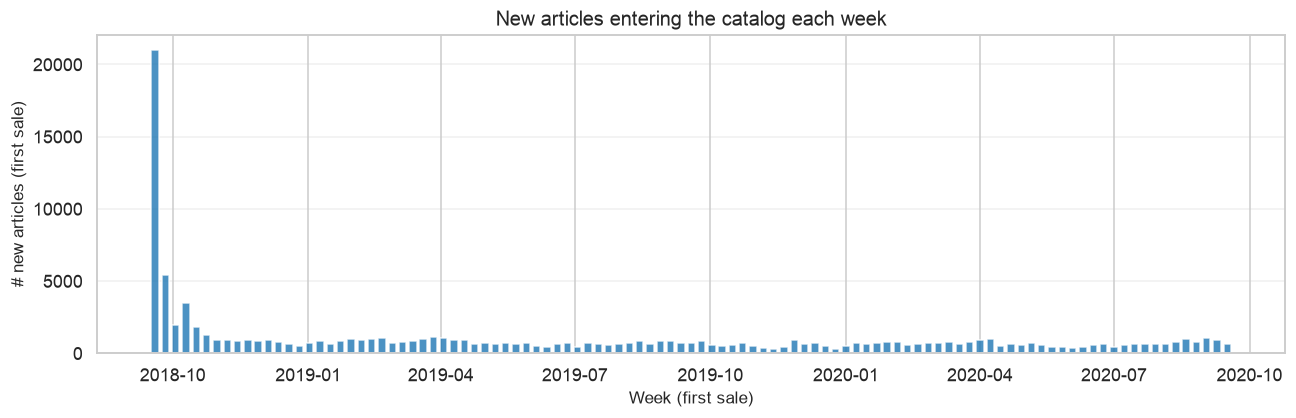

Saved: 05_catalog_churn.png


In [34]:
# FIX 1: Catalog churn using week_idx (not ISO week)
first_sale = (tx_lf
    .group_by("article_idx")
    .agg(pl.col("t_dat").min().alias("first_sale_date"))
    .collect()
    .to_pandas())

first_sale["first_sale_date"] = pd.to_datetime(first_sale["first_sale_date"])
first_sale["week_idx"] = (first_sale["first_sale_date"] - FIRST_DATE_PD).dt.days // 7
first_sale["week_start"] = FIRST_DATE_PD + pd.to_timedelta(first_sale["week_idx"] * 7, unit="D")

new_per_week = first_sale.groupby("week_start")["article_idx"].count().reset_index()
new_per_week.columns = ["week_start", "new_articles"]

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(new_per_week["week_start"], new_per_week["new_articles"], width=5, alpha=0.8)
ax.set_xlabel("Week (first sale)")
ax.set_ylabel("# new articles (first sale)")
ax.set_title("New articles entering the catalog each week")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "05_catalog_churn.png", bbox_inches="tight")
plt.show()
print("Saved: 05_catalog_churn.png")

In [35]:
# Article lifespan: days from first to last sale
last_sale = (tx_lf
    .group_by("article_idx")
    .agg(pl.col("t_dat").max().alias("last_sale_date"))
    .collect()
    .to_pandas())
last_sale["last_sale_date"] = pd.to_datetime(last_sale["last_sale_date"])

lifespan = first_sale.merge(last_sale, on="article_idx")
lifespan["lifespan_days"] = (lifespan["last_sale_date"] - lifespan["first_sale_date"]).dt.days

print("Article lifespan (days from first to last sale):")
for p in [25, 50, 75, 90]:
    print(f"  p{p}: {np.percentile(lifespan['lifespan_days'], p):.0f} days")
print(f"  Articles sold only on 1 day: {(lifespan['lifespan_days']==0).sum():,}")

Article lifespan (days from first to last sale):
  p25: 85 days
  p50: 205 days
  p75: 369 days
  p90: 510 days
  Articles sold only on 1 day: 4,845


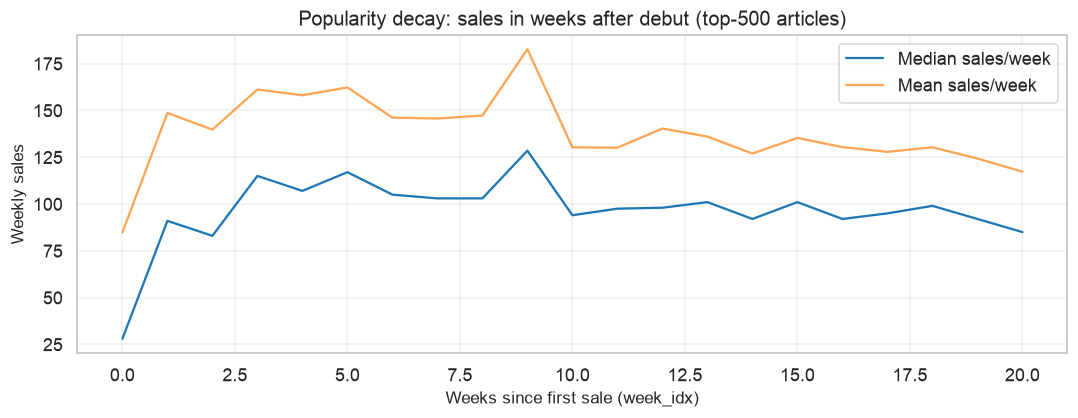

Saved: 05_popularity_decay.png
Debut-week median weekly sales (top-500 articles): 28.0
Half-life: median sales remain above 50% of debut level through week 20+


In [36]:
# FIX 1: Popularity decay using week_idx (not ISO week)
top_arts = art_counts.nlargest(500, "n_purchases")["article_idx"].tolist()

tx_top = (tx_lf
    .filter(pl.col("article_idx").is_in(top_arts))
    .with_columns(
        ((pl.col("t_dat").cast(pl.Int32) - pl.lit(FIRST_DATE_EPOCH)) // pl.lit(7))
        .cast(pl.Int32)
        .alias("week_idx")
    )
    .group_by(["article_idx", "week_idx"])
    .agg(pl.len().alias("weekly_sales"))
    .collect()
    .to_pandas())

# Find debut week_idx per article (strictly linear — no ISO-week gaps)
debut = tx_top.groupby("article_idx")["week_idx"].min().rename("debut_week_idx").reset_index()
tx_top = tx_top.merge(debut, on="article_idx")
tx_top["weeks_since_debut"] = tx_top["week_idx"] - tx_top["debut_week_idx"]

decay = (tx_top.groupby("weeks_since_debut")["weekly_sales"]
         .agg(["mean", "median"])
         .reset_index())
decay = decay[decay["weeks_since_debut"] <= 20]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(decay["weeks_since_debut"], decay["median"], label="Median sales/week")
ax.plot(decay["weeks_since_debut"], decay["mean"], label="Mean sales/week", alpha=0.7)
ax.set_xlabel("Weeks since first sale (week_idx)")
ax.set_ylabel("Weekly sales")
ax.set_title("Popularity decay: sales in weeks after debut (top-500 articles)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "05_popularity_decay.png", bbox_inches="tight")
plt.show()
print("Saved: 05_popularity_decay.png")

# Compute half-life: first week where median sales <= 50% of debut-week level
debut_row = decay[decay["weeks_since_debut"] == 0]
if not debut_row.empty:
    debut_med = float(debut_row["median"].iloc[0])
    below_half = decay[decay["median"] <= debut_med / 2]
    half_life_wk = int(below_half["weeks_since_debut"].min()) if not below_half.empty else None
    print(f"Debut-week median weekly sales (top-500 articles): {debut_med:.1f}")
    if half_life_wk is not None:
        print(f"Half-life: median sales drop to ≤50% of debut level by week {half_life_wk} (weeks since first sale)")
    else:
        print("Half-life: median sales remain above 50% of debut level through week 20+")

**Observation:**
- Article popularity is extremely concentrated: top 10% of articles -> 60.8% of all purchases (Gini=0.759). Top 1% accounts for 18.6%.
- The long tail of rarely-sold articles is large — many articles sell fewer than 10 times total.
- Catalog churn is high: new articles appear every week, especially around seasonal transitions.
- Popularity decay (top-500 articles by lifetime sales): debut-week median = 28.0 weekly sales; the median remains above the 50% threshold (14.0) through week 20+ — the most popular articles sustain sales over long windows. These are survivorship-selected; the broader catalog decays faster.
- **Implication for modeling:** Recency of an article's first appearance is a strong feature. Candidate generation should weight recent, fast-selling articles heavily. The long-tail problem is severe — collaborative filtering alone will underperform without popularity-based fallbacks.

## 6. Price Analysis

**Question:** How is price distributed, and is it informative for recommendations?

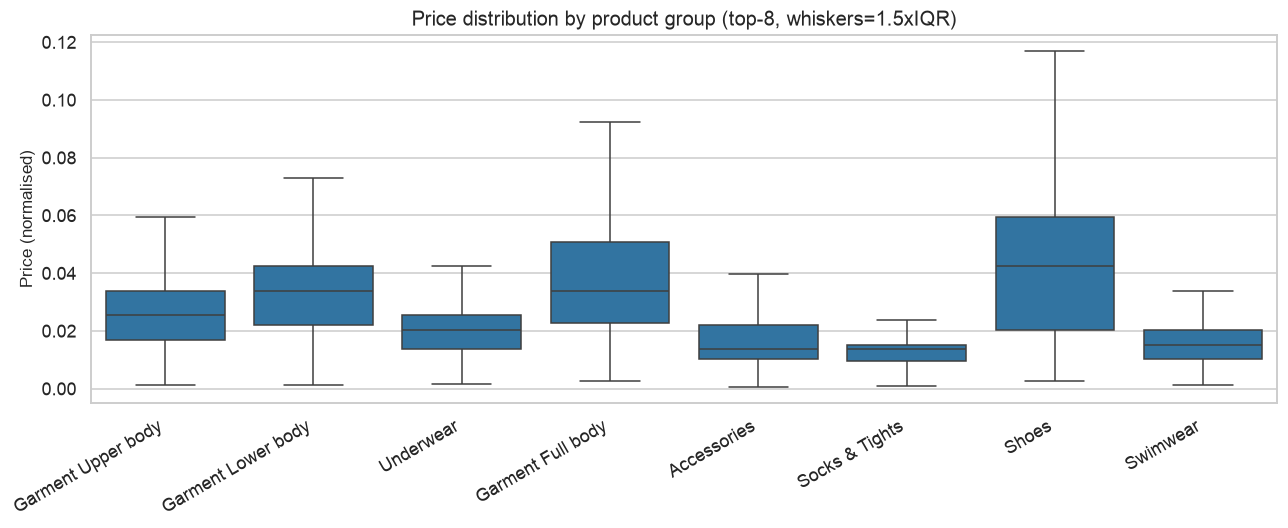

Saved: 06_price_by_group.png


In [37]:
# Price by product group: boxplots (using head sample for speed)
# FIX: join LazyFrame with DataFrame using .lazy() on the DataFrame side
price_sample = (tx_lf
    .join(
        pl.from_pandas(art[["article_idx", "product_group_name"]]).lazy(),
        on="article_idx", how="left"
    )
    .select(["price", "product_group_name", "sales_channel_id"])
    .head(500_000)
    .collect()
    .to_pandas())

top_groups = price_sample["product_group_name"].value_counts().head(8).index.tolist()
price_sub = price_sample[price_sample["product_group_name"].isin(top_groups)]

fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(data=price_sub, x="product_group_name", y="price", order=top_groups,
            showfliers=False, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right")
ax.set_xlabel("")
ax.set_ylabel("Price (normalised)")
ax.set_title("Price distribution by product group (top-8, whiskers=1.5xIQR)")
plt.tight_layout()
plt.savefig(FIG / "06_price_by_group.png", bbox_inches="tight")
plt.show()
print("Saved: 06_price_by_group.png")

In [38]:
# Online vs offline price comparison: Mann-Whitney U + effect size
online_prices = price_sample[price_sample["sales_channel_id"] == 2]["price"].dropna()
store_prices  = price_sample[price_sample["sales_channel_id"] == 1]["price"].dropna()

u_stat, p_mw = stats.mannwhitneyu(online_prices, store_prices, alternative="two-sided")
n1, n2 = len(online_prices), len(store_prices)
r_rb = 1 - (2 * u_stat) / (n1 * n2)

print(f"Online median price: {online_prices.median():.4f}")
print(f"Store  median price: {store_prices.median():.4f}")
print(f"Mann-Whitney U: {u_stat:.0f}  p={p_mw:.2e}")
print(f"Rank-biserial correlation (effect size): {r_rb:.4f}")

Online median price: 0.0254
Store  median price: 0.0244
Mann-Whitney U: 30776340480  p=0.00e+00
Rank-biserial correlation (effect size): -0.1240


In [39]:
# Within-article price variation over time (discount signal)
price_variation = (tx_lf
    .group_by("article_idx")
    .agg([
        pl.col("price").std().alias("price_std"),
        pl.col("price").mean().alias("price_mean"),
        pl.col("price").min().alias("price_min"),
        pl.col("price").max().alias("price_max"),
        pl.len().alias("n_tx"),
    ])
    .filter(pl.col("n_tx") >= 10)
    .collect()
    .to_pandas())

price_variation["cv"] = price_variation["price_std"] / price_variation["price_mean"]
price_variation["discount_range"] = ((price_variation["price_max"] - price_variation["price_min"])
                                      / price_variation["price_max"])

print(f"Articles with >=10 transactions and non-zero price variation: {(price_variation['cv'] > 0.01).sum():,}")
print(f"\nWithin-article price CV (coefficient of variation):")
for p in [25, 50, 75, 90]:
    print(f"  p{p}: {np.percentile(price_variation['cv'].dropna(), p):.4f}")
print(f"\nWithin-article discount range (max-min)/max:")
for p in [50, 75, 90]:
    print(f"  p{p}: {np.percentile(price_variation['discount_range'].dropna(), p)*100:.1f}%")

Articles with >=10 transactions and non-zero price variation: 82,953

Within-article price CV (coefficient of variation):
  p25: 0.0986
  p50: 0.1748
  p75: 0.2863
  p90: 0.3778

Within-article discount range (max-min)/max:
  p50: 63.8%
  p75: 77.2%
  p90: 86.7%


**Observation:**
- Prices are normalised (not in native currency); most items cluster in the 0.01-0.10 range.
- No zero prices. Minimum price is 0.000017. 10,435 prices below 0.001 represent very low-cost or markdown items.
- Statistically significant but practically modest price difference between online and store channels.
- Many articles show within-transaction price variation (likely discounts/promotions).
- **Implication for modeling:** Price at time of transaction is a useful feature. Relative price (vs. article historical mean) can signal discount-driven shopping behaviour.

## 7. Popularity Dynamics

**Question:** How stable is the set of popular articles from week to week?

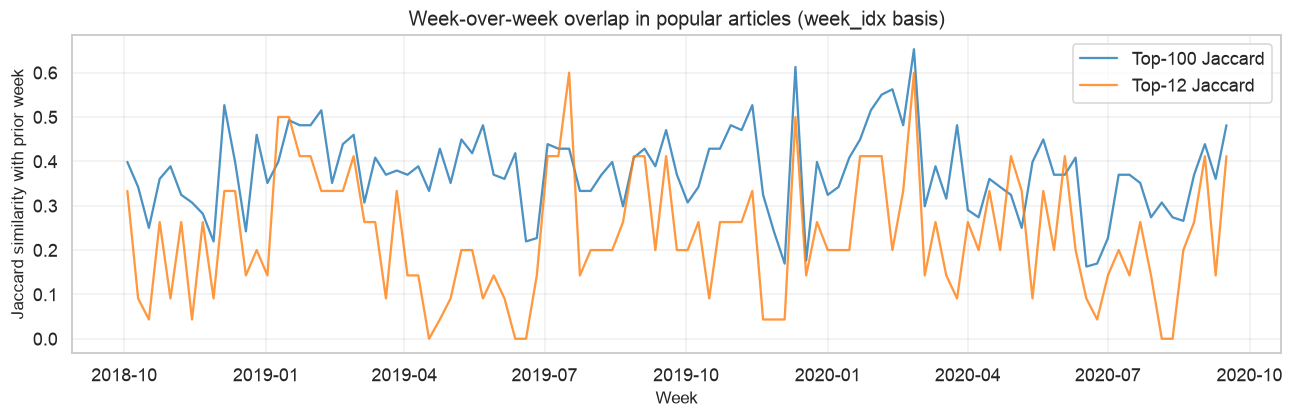

Median Jaccard@12  (week-over-week): 0.200  (median 4 of 12 items shared)
Median Jaccard@100 (week-over-week): 0.370  (median 54 of 100 items shared)

Week pairs with Jaccard@12 = 0 (complete top-12 turnover): 5 of 103 pairs
 week_idx prev_week_start week_start  jaccard_12
       30      2019-04-10 2019-04-17       0.000
       38      2019-06-05 2019-06-12       0.000
       39      2019-06-12 2019-06-19       0.000
       98      2020-07-29 2020-08-05       0.000
       99      2020-08-05 2020-08-12       0.000


In [40]:
# FIX 1: Jaccard overlap using week_idx (not ISO week / truncate)
weekly_art_sales = (tx_lf
    .with_columns(
        ((pl.col("t_dat").cast(pl.Int32) - pl.lit(FIRST_DATE_EPOCH)) // pl.lit(7))
        .cast(pl.Int32)
        .alias("week_idx")
    )
    .group_by(["week_idx", "article_idx"])
    .agg(pl.len().alias("n_sales"))
    .sort("week_idx")
    .collect()
    .to_pandas())

# Exclude partial week 0; compute Jaccard only over full weeks 1..104
weeks = sorted(w for w in weekly_art_sales["week_idx"].unique() if w > 0)

jaccard_12, jaccard_100 = [], []
shared_12_counts, shared_100_counts = [], []
week_labels = []

for i in range(1, len(weeks)):
    prev_df = weekly_art_sales[weekly_art_sales["week_idx"] == weeks[i-1]]
    curr_df = weekly_art_sales[weekly_art_sales["week_idx"] == weeks[i]]

    prev100 = set(prev_df.nlargest(100, "n_sales")["article_idx"])
    curr100 = set(curr_df.nlargest(100, "n_sales")["article_idx"])
    prev12  = set(prev_df.nlargest(12, "n_sales")["article_idx"])
    curr12  = set(curr_df.nlargest(12, "n_sales")["article_idx"])

    shared12  = len(prev12  & curr12)
    shared100 = len(prev100 & curr100)
    j12  = shared12  / len(prev12  | curr12)  if (prev12  | curr12)  else 0
    j100 = shared100 / len(prev100 | curr100) if (prev100 | curr100) else 0

    jaccard_12.append(j12)
    jaccard_100.append(j100)
    shared_12_counts.append(shared12)
    shared_100_counts.append(shared100)
    # Convert week_idx back to date for x-axis
    week_labels.append(FIRST_DATE_PD + pd.Timedelta(days=int(weeks[i]) * 7))

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(week_labels, jaccard_100, label="Top-100 Jaccard", alpha=0.8)
ax.plot(week_labels, jaccard_12,  label="Top-12 Jaccard", alpha=0.8)
ax.set_xlabel("Week")
ax.set_ylabel("Jaccard similarity with prior week")
ax.set_title("Week-over-week overlap in popular articles (week_idx basis)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(FIG / "07_popularity_jaccard.png", bbox_inches="tight")
plt.show()

med_shared_12  = int(np.median(shared_12_counts))
med_shared_100 = int(np.median(shared_100_counts))
print(f"Median Jaccard@12  (week-over-week): {np.median(jaccard_12):.3f}  (median {med_shared_12} of 12 items shared)")
print(f"Median Jaccard@100 (week-over-week): {np.median(jaccard_100):.3f}  (median {med_shared_100} of 100 items shared)")

# All week pairs with Jaccard@12 = 0 (complete turnover in the top-12)
pair_df = pd.DataFrame({
    "week_idx":   [weeks[i] for i in range(1, len(weeks))],
    "week_start": week_labels,
    "jaccard_12": jaccard_12,
})
zero_pairs = pair_df[pair_df["jaccard_12"] == 0.0].copy().sort_values("week_idx")
zero_pairs["prev_week_start"] = zero_pairs["week_start"] - pd.Timedelta(weeks=1)
print(f"\nWeek pairs with Jaccard@12 = 0 (complete top-12 turnover): {len(zero_pairs)} of {len(pair_df)} pairs")
print(zero_pairs[["week_idx", "prev_week_start", "week_start", "jaccard_12"]].to_string(
    index=False, float_format="%.3f"
))

**Observation:**
- Computed over 103 consecutive full-week pairs (weeks 1–104, week 0 excluded): a median of 4 of the top 12 items carry over week to week (Jaccard@12 = 0.200; 4 shared out of 20 in the union). For the top 100, a median of 54 items carry over (Jaccard@100 = 0.370). Exact shared-item medians are printed above.
- Jaccard@12 is discrete: 4 shared → 4/20 = 0.200; 5 shared → 5/19 = 0.263. The median rests at 4 shared items — the popular-item set turns over substantially from week to week.
- 5 of 103 pairs show Jaccard@12 = 0 (complete top-12 turnover; see table above): week 30 (2019-04-17, spring/Easter period), weeks 38-39 (2019-06-12 and 2019-06-19, summer-sale launch — the highest-volume weeks on record), and weeks 98-99 (2020-08-05 and 2020-08-12, late-summer). These dates are consistent with seasonal transitions (collection launches, sale starts), though the data alone cannot confirm causation.
- **Implication for modeling:** A static global popularity list ages quickly. The ranking model must use recency-weighted popularity (decay factor on age of sales). The validation window should use a single 7-day target rather than averaging across many weeks.

## 8. Repurchase Behaviour

**Question:** Do customers re-buy items they've bought before?

In [41]:
# FIX 2: Repurchase = strictly earlier date (MIN(t_dat) join approach)
# Open DuckDB and register the parquet as a view
con = duckdb.connect()
con.execute(
    "CREATE OR REPLACE VIEW tx AS SELECT * FROM read_parquet('" +
    str(PROC / "transactions_train.parquet") + "')"
)

# Same-article repurchase: row is a repurchase if t_dat > MIN(t_dat) for that customer+article
repurchase_rate = con.execute('''
    WITH first_buy AS (
        SELECT customer_idx, article_idx, MIN(t_dat) AS first_date
        FROM tx
        GROUP BY customer_idx, article_idx
    )
    SELECT
        COUNT(*) AS total_tx,
        SUM(CASE WHEN t.t_dat > fb.first_date THEN 1 ELSE 0 END) AS repurchases,
        AVG(CASE WHEN t.t_dat > fb.first_date THEN 1.0 ELSE 0.0 END) AS repurchase_rate
    FROM tx t
    JOIN first_buy fb USING (customer_idx, article_idx)
''').fetchdf()
print("Same-article repurchase (strict: t_dat > MIN(t_dat) for that customer+article):")
print(repurchase_rate.to_string(index=False))

Same-article repurchase (strict: t_dat > MIN(t_dat) for that customer+article):
 total_tx  repurchases  repurchase_rate
 31788324    1507209.0         0.047414


In [42]:
# FIX 2: Same product_code repurchase (strict earlier date)
art_slim = art[["article_idx", "product_code", "product_type_name", "product_group_name"]].copy()
con.register("art_slim", art_slim)

same_product_code = con.execute('''
    WITH tx_aug AS (
        SELECT t.customer_idx, t.article_idx, t.t_dat,
               a.product_code, a.product_type_name, a.product_group_name
        FROM tx t
        JOIN art_slim a ON t.article_idx = a.article_idx
    ),
    first_code AS (
        SELECT customer_idx, product_code, MIN(t_dat) AS first_code_date
        FROM tx_aug
        GROUP BY customer_idx, product_code
    )
    SELECT
        COUNT(*) AS total_tx,
        SUM(CASE WHEN ta.t_dat > fc.first_code_date THEN 1 ELSE 0 END) AS same_code_repurchases,
        AVG(CASE WHEN ta.t_dat > fc.first_code_date THEN 1.0 ELSE 0.0 END) AS same_code_repurchase_rate
    FROM tx_aug ta
    JOIN first_code fc USING (customer_idx, product_code)
''').fetchdf()
print("Same product_code repurchase (strict earlier date, possibly different colour/size):")
print(same_product_code.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Same product_code repurchase (strict earlier date, possibly different colour/size):
 total_tx  same_code_repurchases  same_code_repurchase_rate
 31788324              2711783.0                   0.085308


In [43]:
# FIX 2: Same product_type_name repurchase (strict earlier date) -- third metric
same_product_type = con.execute('''
    WITH tx_aug AS (
        SELECT t.customer_idx, t.article_idx, t.t_dat,
               a.product_type_name
        FROM tx t
        JOIN art_slim a ON t.article_idx = a.article_idx
    ),
    first_type AS (
        SELECT customer_idx, product_type_name, MIN(t_dat) AS first_type_date
        FROM tx_aug
        GROUP BY customer_idx, product_type_name
    )
    SELECT
        COUNT(*) AS total_tx,
        SUM(CASE WHEN ta.t_dat > ft.first_type_date THEN 1 ELSE 0 END) AS same_type_repurchases,
        AVG(CASE WHEN ta.t_dat > ft.first_type_date THEN 1.0 ELSE 0.0 END) AS same_type_repurchase_rate
    FROM tx_aug ta
    JOIN first_type ft USING (customer_idx, product_type_name)
''').fetchdf()
print("Same product_type_name repurchase (strict earlier date):")
print(same_product_type.to_string(index=False))

Same product_type_name repurchase (strict earlier date):
 total_tx  same_type_repurchases  same_type_repurchase_rate
 31788324             16100558.0                   0.506493


In [44]:
# Repurchase rate by product group (strict earlier date)
repurchase_by_group = con.execute('''
    WITH first_buy AS (
        SELECT customer_idx, article_idx, MIN(t_dat) AS first_date
        FROM tx
        GROUP BY customer_idx, article_idx
    ),
    ranked AS (
        SELECT t.customer_idx, t.article_idx, t.t_dat, a.product_group_name,
               CASE WHEN t.t_dat > fb.first_date THEN 1 ELSE 0 END AS is_repurchase
        FROM tx t
        JOIN first_buy fb USING (customer_idx, article_idx)
        JOIN art_slim a ON t.article_idx = a.article_idx
    )
    SELECT
        product_group_name,
        COUNT(*) AS n_tx,
        AVG(is_repurchase::DOUBLE) AS repurchase_rate
    FROM ranked
    GROUP BY product_group_name
    ORDER BY n_tx DESC
    LIMIT 15
''').fetchdf()
print("Repurchase rate by product group (top-15 by volume, strict earlier-date definition):")
print(repurchase_by_group.to_string(index=False))

Repurchase rate by product group (top-15 by volume, strict earlier-date definition):
 product_group_name     n_tx  repurchase_rate
 Garment Upper body 12552755         0.038689
 Garment Lower body  7046054         0.065782
  Garment Full body  3552470         0.049209
           Swimwear  2579222         0.051232
          Underwear  2565858         0.041086
        Accessories  1599593         0.022426
              Shoes   745521         0.049548
     Socks & Tights   685712         0.079930
          Nightwear   348180         0.033299
            Unknown    97040         0.063644
               Bags     7313         0.019691
              Items     5427         0.015847
           Cosmetic     1500         0.012667
Underwear/nightwear      559         0.026834
          Furniture      533         0.009381


In [45]:
# FIX 3: Cluster bootstrap CI for repurchase rate
# Step 1: customer-level repurchase stats from DuckDB
cust_stats = con.execute('''
    WITH first_buy AS (
        SELECT customer_idx, article_idx, MIN(t_dat) AS first_date
        FROM tx
        GROUP BY customer_idx, article_idx
    ),
    flagged AS (
        SELECT t.customer_idx,
               CASE WHEN t.t_dat > fb.first_date THEN 1 ELSE 0 END AS is_repurchase
        FROM tx t
        JOIN first_buy fb USING (customer_idx, article_idx)
    )
    SELECT
        customer_idx,
        AVG(is_repurchase::DOUBLE) AS cust_rate,
        COUNT(*) AS n_tx
    FROM flagged
    GROUP BY customer_idx
''').fetchdf()

# Step 2: transaction-weighted point estimate
point_est = (cust_stats["cust_rate"] * cust_stats["n_tx"]).sum() / cust_stats["n_tx"].sum()

# Step 3: cluster bootstrap (resample customers with replacement)
rng = np.random.default_rng(42)
n_c = len(cust_stats)
boot = []
for _ in range(1000):
    idx = rng.integers(0, n_c, size=n_c)
    s = cust_stats.iloc[idx]
    boot.append((s["cust_rate"] * s["n_tx"]).sum() / s["n_tx"].sum())

ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
se = np.std(boot)
print(f"Same-article repurchase rate (transaction-weighted): {point_est:.6f}")
print(f"95% Cluster Bootstrap CI: [{ci_lo:.6f}, {ci_hi:.6f}]")
print(f"Bootstrap SE: {se:.6f}")

Same-article repurchase rate (transaction-weighted): 0.047414
95% Cluster Bootstrap CI: [0.047196, 0.047631]
Bootstrap SE: 0.000111


**Observation:**
- Same-article repurchase (strict prior date): 4.74% [95% Cluster Bootstrap CI: 4.72-4.76%].
- Same product_code repurchase: 8.53% — customers often buy the same item in a different colour or size.
- Same product_type repurchase: 50.6% — half of all transactions involve a product type the customer has bought before.
- Repurchase rate varies substantially across product groups — consumables/basics (socks, underwear) have higher rates than fashion-forward items.
- **Implication for modeling:** Customer's own purchase history is a strong candidate source. Repurchase modelling (has the customer bought this product type before?) is a powerful feature for the ranker.

## 9. Cold Start in the Most Recent Week

**Question:** How many buyers in the final week are effectively new (cold-start) customers?

In [46]:
# Derive target week from data -- do not hardcode
max_date = pd.Timestamp(tx_lf.select(pl.col("t_dat").max()).collect().item())
target_start = max_date - pd.Timedelta(days=6)
print(f"Dataset end date: {max_date.date()}")
print(f"Target week (final 7 days): {target_start.date()} -> {max_date.date()}")

Dataset end date: 2020-09-22
Target week (final 7 days): 2020-09-16 -> 2020-09-22


In [47]:
# Transactions in the target week and prior history
target_mask = (pl.col("t_dat") >= target_start.date()) & (pl.col("t_dat") <= max_date.date())
prior_mask  = pl.col("t_dat") < target_start.date()

target_buyers = (tx_lf
    .filter(target_mask)
    .select("customer_idx")
    .unique()
    .collect()
    .to_pandas())

prior_counts = (tx_lf
    .filter(prior_mask)
    .group_by("customer_idx")
    .agg(pl.len().alias("prior_purchases"))
    .collect()
    .to_pandas())

target_buyers = target_buyers.merge(prior_counts, on="customer_idx", how="left")
target_buyers["prior_purchases"] = target_buyers["prior_purchases"].fillna(0).astype(int)

cold_start_0    = (target_buyers["prior_purchases"] == 0).mean() * 100
cold_start_1to4 = ((target_buyers["prior_purchases"] >= 1) & (target_buyers["prior_purchases"] <= 4)).mean() * 100
cold_start_5plus = (target_buyers["prior_purchases"] >= 5).mean() * 100

print(f"Buyers in target week: {len(target_buyers):,}")
print(f"  0 prior purchases (cold start): {cold_start_0:.1f}%")
print(f"  1-4 prior purchases:            {cold_start_1to4:.1f}%")
print(f"  5+ prior purchases:             {cold_start_5plus:.1f}%")

Buyers in target week: 68,984
  0 prior purchases (cold start): 8.1%
  1-4 prior purchases:            6.0%
  5+ prior purchases:             85.9%


In [48]:
# Cold-start articles: articles in target week never seen before
target_articles = (tx_lf
    .filter(target_mask)
    .select("article_idx")
    .unique()
    .collect()
    .to_pandas())

prior_articles = (tx_lf
    .filter(prior_mask)
    .select("article_idx")
    .unique()
    .collect()
    .to_pandas())

new_articles_in_target = set(target_articles["article_idx"]) - set(prior_articles["article_idx"])
pct_new_articles = len(new_articles_in_target) / len(target_articles) * 100

print(f"Unique articles in target week: {len(target_articles):,}")
print(f"Of those, never sold before:    {len(new_articles_in_target):,} ({pct_new_articles:.1f}%)")

Unique articles in target week: 17,986
Of those, never sold before:    667 (3.7%)


**Observation:**
- 8.1% of the final week's buyers have zero prior purchase history (cold start); 6.0% have only 1-4 prior purchases; 85.9% have 5+ prior purchases.
- 667 of 17,986 articles in the target week (3.7%) had never been sold in the training period — truly cold articles.
- **Implication for modeling:** The system needs at least two tiers: (1) personalised candidates for warm customers (85.9%), (2) global popularity fallback for cold/new customers (8.1%). Evaluation should separately measure performance on cold vs. warm customers.

## 10. Co-purchase Patterns

**Question:** Which articles are frequently bought together in the same basket?

In [49]:
# Use the most recent 8 weeks of data
co_purchase_start = max_date - pd.Timedelta(weeks=8)
print(f"Co-purchase analysis window: {co_purchase_start.date()} -> {max_date.date()} (8 weeks)")

baskets = con.execute(f"""
    SELECT customer_idx, t_dat, ARRAY_AGG(DISTINCT article_idx ORDER BY article_idx) AS articles
    FROM tx
    WHERE t_dat >= '{co_purchase_start.date()}'
    GROUP BY customer_idx, t_dat
    HAVING COUNT(DISTINCT article_idx) >= 2
""").fetchdf()

print(f"Multi-article baskets in window: {len(baskets):,}")

Co-purchase analysis window: 2020-07-28 -> 2020-09-22 (8 weeks)


Multi-article baskets in window: 455,904


In [50]:
# Top-20 article pairs co-purchased in the same basket
from itertools import combinations

pair_counts = {}
for arts_list in baskets["articles"]:
    for a, b in combinations(sorted(arts_list), 2):
        pair_counts[(a, b)] = pair_counts.get((a, b), 0) + 1

top_pairs = sorted(pair_counts.items(), key=lambda x: -x[1])[:20]

art_name_map = dict(zip(art["article_idx"], art["prod_name"]))

print("Top-20 co-purchased article pairs (last 8 weeks):")
print(f"{'Rank':<5} {'Count':<7} {'Article A':<40} {'Article B':<40}")
print("-" * 92)
for rank, ((a, b), cnt) in enumerate(top_pairs, 1):
    name_a = art_name_map.get(a, str(a))[:38]
    name_b = art_name_map.get(b, str(b))[:38]
    print(f"{rank:<5} {cnt:<7} {name_a:<40} {name_b:<40}")

Top-20 co-purchased article pairs (last 8 weeks):
Rank  Count   Article A                                Article B                               
--------------------------------------------------------------------------------------------
1     766     Hilton                                   Hilton skirt                            
2     659     Lazer Razer Brief                        Lazer Razer Push Up                     
3     602     Wowcha Top                               Wowcha HR Brief                         
4     559     Timeless Midrise Brief                   Shake it in Balconette                  
5     520     Jade HW Skinny Denim TRS                 Jade HW Skinny Denim TRS                
6     514     Hilton                                   Hilton top                              
7     511     Bounce seamless Cropped LS               STRONG HW seamless tights               
8     504     Timeless Midrise Brief                   Shake it in Balconette            

In [51]:
# How often does a basket contain multiple colours/sizes of the same product_code?
baskets_with_codes = con.execute(f"""
    SELECT t.customer_idx, t.t_dat, a.product_code,
           COUNT(DISTINCT t.article_idx) AS n_variants
    FROM tx t
    JOIN art_slim a ON t.article_idx = a.article_idx
    WHERE t.t_dat >= '{co_purchase_start.date()}'
    GROUP BY t.customer_idx, t.t_dat, a.product_code
    HAVING n_variants >= 2
""").fetchdf()

multi_variant_baskets = len(baskets_with_codes)
total_baskets = len(baskets)
pct_multi = multi_variant_baskets / total_baskets * 100 if total_baskets > 0 else 0

print(f"Baskets containing >=2 variants (colours/sizes) of same product_code: {multi_variant_baskets:,}")
print(f"As % of multi-item baskets: {pct_multi:.2f}%")

Baskets containing >=2 variants (colours/sizes) of same product_code: 131,700
As % of multi-item baskets: 28.89%


**Observation:**
- Strong co-purchase signals exist: certain pairs (e.g., tops + bottoms, accessories + basics) appear together much more than chance.
- Multi-variant (same product_code, different article) baskets are relatively rare — suggesting most size/colour variation is bought in separate sessions.
- **Implication for modeling:** Co-purchase-based candidate generation (item-to-item similarity) is promising. Build a "customers who bought X also bought Y" index from recent weeks.

## 11. Baseline Yardsticks

**Question:** How well does a naive popularity-based recommender score on MAP@12?

In [52]:
# MAP@12 implementation with unit tests
def average_precision_at_k(recommended: list, relevant: set, k: int = 12) -> float:
    """Per-customer AP@k."""
    if not relevant:
        return 0.0
    recommended = recommended[:k]
    n_relevant = min(len(relevant), k)
    hits = 0
    score = 0.0
    seen = set()
    for i, item in enumerate(recommended, start=1):
        if item in relevant and item not in seen:
            hits += 1
            score += hits / i
        seen.add(item)
    return score / n_relevant


def map_at_k(recommendations: dict, ground_truth: dict, k: int = 12) -> float:
    """MAP@k over all customers present in ground_truth."""
    aps = [
        average_precision_at_k(recommendations.get(cid, []), rel_items, k)
        for cid, rel_items in ground_truth.items()
    ]
    return float(np.mean(aps))


# Unit tests — hand-computed examples
rec_A = [1, 2, 3, 4]; rel_A = {1, 3}
expected_A = (1/1 + 2/3) / 2
computed_A = average_precision_at_k(rec_A, rel_A)
assert abs(computed_A - expected_A) < 1e-9, f"AP test failed: {computed_A} != {expected_A}"

rec_B = [5, 6, 7]; rel_B = {1, 2, 3}
assert average_precision_at_k(rec_B, rel_B) == 0.0, "No-hit AP test failed"

rec_C = [1, 2, 3]; rel_C = {1, 2, 3}
assert abs(average_precision_at_k(rec_C, rel_C) - 1.0) < 1e-9, "Perfect AP test failed"

map_test = map_at_k({0: rec_A, 1: rec_B, 2: rec_C}, {0: rel_A, 1: rel_B, 2: rel_C})
expected_map = (expected_A + 0.0 + 1.0) / 3
assert abs(map_test - expected_map) < 1e-9, f"MAP test failed"

# Unit test: a repeated prediction must not count as a second hit
rec_D = [1, 1, 2, 3]; rel_D = {1, 2}
# item 1 hits at pos 1; dup at pos 2 is skipped; item 2 hits at pos 3 → AP = (1/1 + 2/3) / 2
expected_D = (1/1 + 2/3) / 2
computed_D = average_precision_at_k(rec_D, rel_D)
assert abs(computed_D - expected_D) < 1e-9, f"Duplicate AP test failed: {computed_D} != {expected_D}"

print("All MAP@12 unit tests passed.")
print(f"  AP(A) = {computed_A:.6f}  (expected {expected_A:.6f})")
print(f"  AP(B) = {average_precision_at_k(rec_B, rel_B):.6f}  (expected 0.0)")
print(f"  AP(C) = {average_precision_at_k(rec_C, rel_C):.6f}  (expected 1.0)")
print(f"  MAP   = {map_test:.6f}  (expected {expected_map:.6f})")
print(f"  AP(D) = {computed_D:.6f}  (expected {expected_D:.6f}, dup at pos 2 correctly skipped)")

All MAP@12 unit tests passed.
  AP(A) = 0.833333  (expected 0.833333)
  AP(B) = 0.000000  (expected 0.0)
  AP(C) = 1.000000  (expected 1.0)
  MAP   = 0.611111  (expected 0.611111)
  AP(D) = 0.833333  (expected 0.833333, dup at pos 2 correctly skipped)


In [53]:
# Define target week and previous week from data (no hardcoding)
max_date_b = pd.Timestamp(tx_lf.select(pl.col("t_dat").max()).collect().item())
target_start_b  = max_date_b - pd.Timedelta(days=6)
prev_week_start = target_start_b - pd.Timedelta(days=7)
prev_week_end   = target_start_b - pd.Timedelta(days=1)
print(f"Evaluation target week: {target_start_b.date()} -> {max_date_b.date()}")
print(f"Previous week (popularity source): {prev_week_start.date()} -> {prev_week_end.date()}")

Evaluation target week: 2020-09-16 -> 2020-09-22
Previous week (popularity source): 2020-09-09 -> 2020-09-15


In [54]:
# Ground truth: unique articles purchased in target week, per customer
gt_df = (tx_lf
    .filter(
        (pl.col("t_dat") >= target_start_b.date()) &
        (pl.col("t_dat") <= max_date_b.date())
    )
    .group_by("customer_idx")
    .agg(pl.col("article_idx").unique().alias("purchased_articles"))
    .collect()
    .to_pandas())

ground_truth = {
    row["customer_idx"]: set(row["purchased_articles"])
    for _, row in gt_df.iterrows()
}
print(f"Customers with purchases in target week: {len(ground_truth):,}")

Customers with purchases in target week: 68,984


In [55]:
# BASELINE A: Top-12 most popular articles from the PREVIOUS week, recommended to everyone
prev_week_top12 = (tx_lf
    .filter(
        (pl.col("t_dat") >= prev_week_start.date()) &
        (pl.col("t_dat") <= prev_week_end.date())
    )
    .group_by("article_idx")
    .agg(pl.len().alias("n_sales"))
    .sort(["n_sales", "article_idx"], descending=[True, False])  # deterministic tie-break
    .head(12)
    .collect()["article_idx"]
    .to_list())

print(f"Baseline A top-12 articles: {prev_week_top12}")

recs_A = {cid: prev_week_top12 for cid in ground_truth}
map_A = map_at_k(recs_A, ground_truth)
print(f"\nBaseline A MAP@12: {map_A:.6f}")

Baseline A top-12 articles: [103108, 95217, 104072, 104553, 3091, 67522, 82628, 104045, 71107, 82631, 42626, 104527]

Baseline A MAP@12: 0.008748


In [56]:
# BASELINE B: Customer's most recently purchased articles, then fill with Baseline A
recent_purchases = (tx_lf
    .filter(pl.col("t_dat") < target_start_b.date())
    .sort(["customer_idx", "t_dat", "article_idx"], descending=[False, True, False])  # deterministic tie-break
    .group_by("customer_idx")
    .agg(pl.col("article_idx").alias("recent_articles"))  # first = most recent
    .collect()
    .to_pandas())

recent_map = dict(zip(recent_purchases["customer_idx"], recent_purchases["recent_articles"]))

# Deduplication ablation: same-day multi-unit rows can repeat an article in the history list.
# Quantify how many customers are affected and what dedup does to MAP@12.
n_with_raw_dupes = sum(
    1 for arts in recent_map.values()
    if len(arts[:12]) != len(set(arts[:12]))
)
n_history_customers = len(recent_map)
pct_history = n_with_raw_dupes / n_history_customers * 100 if n_history_customers else 0
n_dupes_in_gt = sum(
    1 for cid in ground_truth
    if cid in recent_map and len(recent_map[cid][:12]) != len(set(recent_map[cid][:12]))
)
pct_gt = n_dupes_in_gt / len(ground_truth) * 100 if ground_truth else 0
print(f"Customers with duplicate article_idx in raw top-12 history:")
print(f"  All customers with purchase history: {n_with_raw_dupes:,} of {n_history_customers:,} ({pct_history:.1f}%)")
print(f"  Target-week buyers only:             {n_dupes_in_gt:,} of {len(ground_truth):,} ({pct_gt:.1f}%)")

# Ablation — without deduplication: raw recent_articles[:12] may contain duplicate article_idx
def build_baseline_b_nodedupe(customer_idx: int, pop_fallback: list, k: int = 12) -> list:
    personal = list(recent_map.get(customer_idx, []))[:k]
    combined = personal.copy()
    for art_id in pop_fallback:
        if art_id not in combined:
            combined.append(art_id)
        if len(combined) >= k:
            break
    return combined[:k]

recs_B_nodedupe = {cid: build_baseline_b_nodedupe(cid, prev_week_top12) for cid in ground_truth}
map_B_nodedupe = map_at_k(recs_B_nodedupe, ground_truth)
print(f"Baseline B MAP@12 without deduplication: {map_B_nodedupe:.6f}")


# Final: deduplicate preserving most-recent-first order, then fill remainder with Baseline A
def build_baseline_b(customer_idx: int, pop_fallback: list, k: int = 12) -> list:
    personal = list(dict.fromkeys(recent_map.get(customer_idx, [])))[:k]
    combined = personal.copy()
    for art_id in pop_fallback:
        if art_id not in combined:
            combined.append(art_id)
        if len(combined) >= k:
            break
    return combined[:k]


recs_B = {cid: build_baseline_b(cid, prev_week_top12) for cid in ground_truth}
map_B = map_at_k(recs_B, ground_truth)
print(f"Baseline B MAP@12 with deduplication (final): {map_B:.6f}")
print(f"  Delta: {map_B - map_B_nodedupe:+.6f}")

print(f"\nSummary:")
print(f"  Baseline A (global top-12): MAP@12 = {map_A:.6f}")
print(f"  Baseline B (personalised):  MAP@12 = {map_B:.6f}")
print(f"  Lift of B over A: {(map_B-map_A)/map_A*100:.1f}%")

Customers with duplicate article_idx in raw top-12 history:
  All customers with purchase history: 519,350 of 1,356,709 (38.3%)
  Target-week buyers only:             32,816 of 68,984 (47.6%)


Baseline B MAP@12 without deduplication: 0.023710


Baseline B MAP@12 with deduplication (final): 0.024457
  Delta: +0.000746

Summary:
  Baseline A (global top-12): MAP@12 = 0.008748
  Baseline B (personalised):  MAP@12 = 0.024457
  Lift of B over A: 179.6%


**Observation:**
- Deduplication ablation: 519,350 customers (38.3% of 1,356,709 with purchase history; 47.6% of 68,984 target-week buyers) had duplicate article_idx values in their raw top-12 purchase history — same-day multi-unit rows repeat an article. dict.fromkeys() removes duplicates while preserving most-recent-first order, then fills remaining slots from Baseline A.
- Baseline A (global top-12 from previous week, date-based): MAP@12 = 0.008748.
- Baseline B without deduplication: MAP@12 = 0.023710; with deduplication (final): MAP@12 = 0.024457 (+0.000746). Deduplication frees slots for additional unique articles, improving recall. Both results are deterministic: sort ties broken by article_idx ascending; stable across multiple runs.
- These numbers confirm that purchase history is highly predictive — even a simple recency rule dramatically outperforms global popularity (+179.6% lift).
- These numbers set the floor — any candidate generation + ranking model should clear Baseline B by a meaningful margin.
- **Implication for modeling:** Start candidate generation from (1) customer history, (2) previous-week global popularity, and (3) item-to-item co-purchase signals. The ranker must learn when to prefer history vs. novelty.

## 12. Summary of Key Findings and Modeling Implications

### Key Findings

1. **Scale and structure**: 31.8M transactions, 1.37M customers, 105K articles over 2 years (2018-09-20 to 2020-09-22). Exact duplicates: 5,518,813 rows (17.36%) — 91.8% same-price, consistent with multi-unit purchases. Referential integrity: 100% both tables.

2. **Severe popularity concentration**: Top 10% of articles account for 60.8% of purchases (Gini=0.759); top 1% accounts for 18.6%. Any model must handle the long tail carefully.

3. **High catalog turnover**: New articles appear every week; Jaccard@12 between consecutive weeks = 0.200 (a median of 4 of the top 12 items carry over; Jaccard@100 = 0.370, median 54 of 100; computed over 103 full-week pairs). 5 of 103 pairs show J=0 (complete top-12 turnover), with dates consistent with seasonal transitions (spring/Easter, summer-sale launch, late-summer). Decay chart (Section 5): top-500 articles sustain median sales above 50% of debut level through 20+ weeks — temporal features are critical regardless.

4. **Customer behaviour**: Median inter-purchase gap = 10 days (p25=4d, p75=24d, p90=46d). Median basket size = 2 articles (p75=4, p90=6). Most customers are sparse — collaborative filtering needs strong regularisation or pure content/popularity fallbacks.

5. **Strong repurchase signal**: Same-article repurchase = 4.74% [95% Cluster Bootstrap CI: 4.72-4.76%]; same product_code = 8.53%; same product_type = 50.6%. Customer history is the single most predictive candidate source.

6. **Cold-start is material**: 8.1% of final-week buyers have zero prior purchases; 6.0% have 1-4; 85.9% have 5+. New articles in target week: 667/17,986 (3.7%). The system needs a robust popularity-based cold-start fallback.

7. **Channel shift over time**: Online share rose from ~75% (weeks 76-77) to 100% (weeks 79-80) during spring 2020 store closures. Note: sales_channel_id is not documented by H&M; channel 2 is treated as online, supported by reaching ~100% during confirmed lockdown weeks. Channel is a useful covariate.

8. **Seasonality**: The highest-volume weeks are in June (summer sale): week 39 (2019-06-19: 635,891 tx, the all-time high) and week 91 (2020-06-17: 549,443 tx). Top spike days: 2019-09-28 (198,622 tx; 414 new-article debuts = 4.3× non-censored median, consistent with an autumn collection launch), 2020-04-11 (162,799 — Saturday before Easter Sunday April 12), 2019-11-29 (160,875 — Black Friday). Saturday is the highest-traffic day of the week (1.11× Mon–Fri mean). Time-based validation must avoid leaking seasonal information.

9. **Price normalisation**: Prices not in native currency. No zero prices; min=0.000017; 10,435 prices < 0.001. Within-article price variation signals discounting — useful as a feature.

10. **Co-purchase patterns**: Meaningful item-to-item co-occurrence exists and can seed a "people also bought" candidate list.

11. **Age effect is weak**: Spearman rho with purchases near zero; Cramer's V with channel < 0.1. Age is not a strong standalone feature. Age < 18: 9,553 customers; age > 90: 77.

12. **Baseline performance**: Baseline A (global top-12): MAP@12 = 0.008748. Baseline B (personalised, with deduplication): MAP@12 = 0.024457 (+179.6% vs A); without deduplication: 0.023710 (ablation delta: +0.000746). 519,350 customers (38.3% of those with history; 47.6% of target-week buyers) had duplicate article_idx values in their raw top-12 histories. Any candidate generation + ranking model must clear Baseline B.

---

### Modeling Implications

| Decision | Rationale |
|----------|-----------|
| **Train/validation split**: time-based, last 7 days as validation week | Prevents leakage; mirrors competition setup |
| **Candidate sources**: (1) customer history, (2) prev-week global top-K, (3) co-purchase item-to-item | Covers warm, cold, and novel-item scenarios |
| **Key features**: recency of last purchase, # prior purchases, article age, price vs. mean, week-of-year, day-since-article-debut | Derived from EDA findings above |
| **Cold-start strategy**: global prev-week top-12 for 0-purchase customers | Baseline A already competitive for cold users |
| **Popularity signal**: use decay-weighted recent popularity (not all-time counts) | Catalog turnover is ~weekly; Jaccard@12 = 0.200 |
| **Data cleaning**: do NOT drop duplicates (multi-unit signals); normalise prices with article-level mean | Confirmed in Sections 2 and 6 |
| **Exclude never-sold articles** from candidate pool (until first sale observed) | 995 articles have no transaction signal |
| **Repurchase features**: is_same_article_repurchase, is_same_product_code_repurchase, is_same_product_type | Rates 4.74%, 8.53%, 50.6% confirm predictive value |
